In [357]:
import pandas as pd
from pathlib import Path

years = ['2021', '2022', '2023', '2024']

dfs = [pd.read_csv(f"atp_matches_{year}.csv") for year in years]
df = pd.concat(dfs, ignore_index=True)

print(df.shape)
print(df.info())

(11712, 49)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11712 entries, 0 to 11711
Data columns (total 49 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tourney_id          11712 non-null  object 
 1   tourney_name        11712 non-null  object 
 2   surface             11659 non-null  object 
 3   draw_size           11712 non-null  int64  
 4   tourney_level       11712 non-null  object 
 5   tourney_date        11712 non-null  int64  
 6   match_num           11712 non-null  int64  
 7   winner_id           11712 non-null  int64  
 8   winner_seed         4929 non-null   float64
 9   winner_entry        1795 non-null   object 
 10  winner_name         11712 non-null  object 
 11  winner_hand         11712 non-null  object 
 12  winner_ht           11665 non-null  float64
 13  winner_ioc          11712 non-null  object 
 14  winner_age          11710 non-null  float64
 15  loser_id            11712 non-null  int64

In [358]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [359]:
import pandas as pd
from sklearn.utils import shuffle

# Step 1: Copy data
df_model = df.copy()

# Step 2: Drop post-match info
post_match_cols = [col for col in df_model.columns if col.startswith(('w_', 'l_'))] + ['score', 'minutes', 'winner_rank_points', 'loser_rank_points']
df_model.drop(columns=post_match_cols, inplace=True)

# Step 3: Fill and clean pre-match features
df_model['winner_seed'].fillna(0, inplace=True)
df_model['loser_seed'].fillna(0, inplace=True)
df_model['winner_entry'].fillna('N', inplace=True)
df_model['loser_entry'].fillna('N', inplace=True)

for col in ['winner_age', 'loser_age', 'winner_ht', 'loser_ht']:
    df_model[col].fillna(df_model[col].median(), inplace=True)

df_model.dropna(subset=['winner_rank', 'loser_rank'], inplace=True)

df_model['tourney_date'] = pd.to_datetime(df_model['tourney_date'], format='%Y%m%d')
df_model['year'] = df_model['tourney_date'].dt.year

round_order = {'R128':1, 'R64':2, 'R32':3, 'R16':4, 'QF':5, 'SF':6, 'F':7}
df_model['round_encoded'] = df_model['round'].map(round_order)

# Step 4: Rename columns and create symmetrical dataset
def create_symmetric_rows(row):
    p1 = {
        'player_1': row['winner_name'],
        'player_2': row['loser_name'],
        'p1_rank': row['winner_rank'],
        'p2_rank': row['loser_rank'],
        'p1_age': row['winner_age'],
        'p2_age': row['loser_age'],
        'p1_ht': row['winner_ht'],
        'p2_ht': row['loser_ht'],
        'p1_seed': row['winner_seed'],
        'p2_seed': row['loser_seed'],
        'surface': row['surface'],
        'round': row['round_encoded'],
        'year': row['year'],
        'target': 1
    }
    p2 = p1.copy()
    p2['player_1'], p2['player_2'] = p1['player_2'], p1['player_1']
    p2['p1_rank'], p2['p2_rank'] = p1['p2_rank'], p1['p1_rank']
    p2['p1_age'], p2['p2_age'] = p1['p2_age'], p1['p1_age']
    p2['p1_ht'], p2['p2_ht'] = p1['p2_ht'], p1['p1_ht']
    p2['p1_seed'], p2['p2_seed'] = p1['p2_seed'], p1['p1_seed']
    p2['target'] = 0
    return pd.DataFrame([p1, p2])

symmetric_df = pd.concat([create_symmetric_rows(row) for _, row in df_model.iterrows()], ignore_index=True)
symmetric_df = shuffle(symmetric_df, random_state=42).reset_index(drop=True)

In [360]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.model_selection import train_test_split

# Only use numeric features + surface/round for now
feature_cols = [
    'p1_rank', 'p2_rank',
    'p1_age', 'p2_age',
    'p1_ht', 'p2_ht',
    'p1_seed', 'p2_seed',
    'round',  # encoded
    'surface'
]

# One-hot encode categorical column
X = pd.get_dummies(symmetric_df[feature_cols], columns=['surface'])
y = symmetric_df['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [361]:
# Check how many NaNs are in your training set
print("NaNs in X_train:", X_train.isnull().sum().sum())
print("NaNs in y_train:", y_train.isnull().sum())

NaNs in X_train: 1521
NaNs in y_train: 0


In [362]:
# Drop rows with NaNs from X and align y accordingly
X_train_clean = X_train.dropna()
y_train_clean = y_train.loc[X_train_clean.index]

X_test_clean = X_test.dropna()
y_test_clean = y_test.loc[X_test_clean.index]

# Fit the model on cleaned data
model = LogisticRegression(max_iter=1000)
model.fit(X_train_clean, y_train_clean)

# Predict and evaluate
y_pred = model.predict(X_test_clean)
print("Accuracy:", accuracy_score(y_test_clean, y_pred))

Accuracy: 0.6127739806740514


In [363]:
round_order = {'R128': 1, 'R64': 2, 'R32': 3, 'R16': 4, 'QF': 5, 'SF': 6, 'F': 7}
df['round_encoded'] = df['round'].map(round_order)

In [364]:
# 1. Create 'player 1' = winner, 'player 2' = loser columns
df['p1_rank'] = df['winner_rank']
df['p2_rank'] = df['loser_rank']

df['p1_age'] = df['winner_age']
df['p2_age'] = df['loser_age']

df['p1_ht'] = df['winner_ht']
df['p2_ht'] = df['loser_ht']

df['p1_seed'] = df['winner_seed'].fillna(0)
df['p2_seed'] = df['loser_seed'].fillna(0)

# 2. Encode 'round'
round_order = {'R128': 1, 'R64': 2, 'R32': 3, 'R16': 4, 'QF': 5, 'SF': 6, 'F': 7}
df['round_encoded'] = df['round'].map(round_order)

# 3. One-hot encode surface
surface_dummies = pd.get_dummies(df['surface'], prefix='surface')
df = pd.concat([df, surface_dummies], axis=1)

# 4. Define the outcome (player 1 = winner)
df['outcome'] = 1

In [365]:
def create_symmetrical_df(df_original):
    rows = []
    for _, row in df_original.iterrows():
        # Player 1 = winner
        row1 = {
            'p1_rank': row['winner_rank'],
            'p2_rank': row['loser_rank'],
            'p1_age': row['winner_age'],
            'p2_age': row['loser_age'],
            'p1_ht': row['winner_ht'],
            'p2_ht': row['loser_ht'],
            'p1_seed': row['winner_seed'] if pd.notnull(row['winner_seed']) else 0,
            'p2_seed': row['loser_seed'] if pd.notnull(row['loser_seed']) else 0,
            'round_encoded': round_order.get(row['round'], 0),
            'surface': row['surface'],
            'outcome': 1
        }

        # Player 1 = loser
        row2 = {
            'p1_rank': row['loser_rank'],
            'p2_rank': row['winner_rank'],
            'p1_age': row['loser_age'],
            'p2_age': row['winner_age'],
            'p1_ht': row['loser_ht'],
            'p2_ht': row['winner_ht'],
            'p1_seed': row['loser_seed'] if pd.notnull(row['loser_seed']) else 0,
            'p2_seed': row['winner_seed'] if pd.notnull(row['winner_seed']) else 0,
            'round_encoded': round_order.get(row['round'], 0),
            'surface': row['surface'],
            'outcome': 0
        }

        rows.append(row1)
        rows.append(row2)

    return pd.DataFrame(rows)

# Create symmetrical dataset
df_symmetric = create_symmetrical_df(df)

In [366]:
# One-hot encode surface
surface_dummies = pd.get_dummies(df_symmetric['surface'], prefix='surface')
df_symmetric = pd.concat([df_symmetric, surface_dummies], axis=1)

# Define final feature list
features = ['p1_rank', 'p2_rank', 'p1_age', 'p2_age', 'p1_ht', 'p2_ht',
            'p1_seed', 'p2_seed', 'round_encoded'] + list(surface_dummies.columns)

# Prepare data
X = df_symmetric[features].dropna()
y = df_symmetric.loc[X.index, 'outcome']

# Train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict & evaluate
from sklearn.metrics import accuracy_score, classification_report
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.629018245004344
Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.65      0.63      2264
           1       0.64      0.61      0.63      2340

    accuracy                           0.63      4604
   macro avg       0.63      0.63      0.63      4604
weighted avg       0.63      0.63      0.63      4604



In [367]:
import re

def parse_score(score):
    if pd.isnull(score):
        return None, None

    sets = score.strip().split()
    winner_sets = 0
    loser_sets = 0
    games_winner = 0
    games_loser = 0

    for s in sets:
        s = re.sub(r'[^\d\-]', '', s)  # strip any tiebreak junk
        if '-' not in s:
            continue
        try:
            g1, g2 = map(int, s.split('-'))
        except ValueError:
            continue

        if g1 > g2:
            winner_sets += 1
            games_winner += g1
            games_loser += g2
        else:
            loser_sets += 1
            games_winner += g2
            games_loser += g1

    sets_lost = loser_sets
    if games_winner + games_loser == 0:
        game_win_pct = None
    else:
        game_win_pct = games_winner / (games_winner + games_loser)

    return sets_lost, game_win_pct

# Apply to your original dataset
df['sets_lost'], df['game_win_pct'] = zip(*df['score'].map(parse_score))

In [368]:
from sklearn.linear_model import LinearRegression

def create_symmetrical_df(df_original):
    rows = []
    for _, row in df_original.iterrows():
        row1 = {
            'p1_rank': row['winner_rank'],
            'p2_rank': row['loser_rank'],
            'p1_age': row['winner_age'],
            'p2_age': row['loser_age'],
            'p1_ht': row['winner_ht'],
            'p2_ht': row['loser_ht'],
            'p1_seed': row['winner_seed'] if pd.notnull(row['winner_seed']) else 0,
            'p2_seed': row['loser_seed'] if pd.notnull(row['loser_seed']) else 0,
            'round_encoded': row['round_encoded'],
            'surface': row['surface'],
            'sets_lost': row['sets_lost'],
            'game_win_pct': row['game_win_pct'],
            'outcome': 1
        }
        row2 = {
            'p1_rank': row['loser_rank'],
            'p2_rank': row['winner_rank'],
            'p1_age': row['loser_age'],
            'p2_age': row['winner_age'],
            'p1_ht': row['loser_ht'],
            'p2_ht': row['winner_ht'],
            'p1_seed': row['loser_seed'] if pd.notnull(row['loser_seed']) else 0,
            'p2_seed': row['winner_seed'] if pd.notnull(row['winner_seed']) else 0,
            'round_encoded': row['round_encoded'],
            'surface': row['surface'],
            'sets_lost': 3 - row['sets_lost'] if row['sets_lost'] is not None else None,
            'game_win_pct': 1 - row['game_win_pct'] if row['game_win_pct'] is not None else None,
            'outcome': 0
        }
        rows.extend([row1, row2])
    return pd.DataFrame(rows)

In [369]:
df_symmetric = create_symmetrical_df(df)

In [370]:
y_sets_lost = df_symmetric.loc[X.index, 'sets_lost']

In [371]:
# One-hot encode surface
surface_dummies = pd.get_dummies(df_symmetric['surface'], prefix='surface')
df_symmetric = pd.concat([df_symmetric, surface_dummies], axis=1)

# Update features list
features = ['p1_rank', 'p2_rank', 'p1_age', 'p2_age',
            'p1_ht', 'p2_ht', 'p1_seed', 'p2_seed',
            'round_encoded', 'surface_Clay', 'surface_Grass', 'surface_Hard']

In [372]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split

# Ensure X and targets are aligned and clean
X = df_symmetric[features].dropna()

# Align targets with cleaned X
y_sets_lost = df_symmetric.loc[X.index, 'sets_lost']
y_game_pct = df_symmetric.loc[X.index, 'game_win_pct']
y_outcome = df_symmetric.loc[X.index, 'outcome']

# Drop any rows with missing targets
mask = y_sets_lost.notnull() & y_game_pct.notnull() & y_outcome.notnull()
X = X[mask]
y_sets_lost = y_sets_lost[mask]
y_game_pct = y_game_pct[mask]
y_outcome = y_outcome[mask]

# Train/test split for classifiers and regressors
X_train, X_test, y_outcome_train, y_outcome_test = train_test_split(X, y_outcome, test_size=0.2, random_state=42)
X_train_sets, X_test_sets, y_sets_train, y_sets_test = train_test_split(X, y_sets_lost, test_size=0.2, random_state=42)
X_train_games, X_test_games, y_games_train, y_games_test = train_test_split(X, y_game_pct, test_size=0.2, random_state=42)

# Train models
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_outcome_train)

sets_model = LinearRegression()
sets_model.fit(X_train_sets, y_sets_train)

games_model = LinearRegression()
games_model.fit(X_train_games, y_games_train)

# Inference function
def predict_match(input_features):
    win_prob = model.predict_proba([input_features])[0][1]
    predicted_winner = "Player 1" if win_prob > 0.5 else "Player 2"
    expected_sets_lost = sets_model.predict([input_features])[0]
    expected_game_win_pct = games_model.predict([input_features])[0]

    return {
        "predicted_winner": predicted_winner,
        "win_probability": round(win_prob, 2),
        "expected_sets_lost": round(expected_sets_lost, 2),
        "expected_game_win_pct": round(expected_game_win_pct, 2)
    }

In [373]:
import numpy as np

# Sample input row (ensure it's float type)
sample_input = X.iloc[0].values.astype(np.float64)

# Run prediction
result = predict_match(sample_input)
print(result)

{'predicted_winner': 'Player 1', 'win_probability': 0.55, 'expected_sets_lost': 1.37, 'expected_game_win_pct': 0.52}


c:\Users\SAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\SAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\SAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [374]:
df['delta_aces'] = df['w_ace'] - df['l_ace']

df['delta_1stServePct'] = (df['w_1stIn'] / df['w_svpt']) - (df['l_1stIn'] / df['l_svpt'])

df['delta_1stServeWinPct'] = (df['w_1stWon'] / df['w_1stIn']) - (df['l_1stWon'] / df['l_1stIn'])

df['delta_2ndServeWinPct'] = (df['w_2ndWon'] / (df['w_svpt'] - df['w_1stIn'])) - (df['l_2ndWon'] / (df['l_svpt'] - df['l_1stIn']))

df['delta_bpSavedPct'] = (df['w_bpSaved'] / df['w_bpFaced'].replace(0, 1)) - (df['l_bpSaved'] / df['l_bpFaced'].replace(0, 1))

df['delta_df'] = df['w_df'] - df['l_df']

df['delta_svpt'] = df['w_svpt'] - df['l_svpt']

df['delta_rank'] = df['loser_rank'] - df['winner_rank']  # higher rank = lower number, so we reverse

features = [
    'delta_aces',
    'delta_1stServePct',
    'delta_1stServeWinPct',
    'delta_2ndServeWinPct',
    'delta_bpSavedPct',
    'delta_df',
    'delta_svpt',
    'delta_rank'
]

In [375]:
import numpy as np

custom_input = np.array([
    3,    # p1_rank
    12,   # p2_rank
    26,   # p1_age
    30,   # p2_age
    188,  # p1_ht
    185,  # p2_ht
    2,    # p1_seed
    0,    # p2_seed
    5,    # round_encoded (QF)
    0,    # surface_Clay
    1,    # surface_Grass
    0     # surface_Hard
], dtype=np.float64)

result = predict_match(custom_input)
print(result)

{'predicted_winner': 'Player 1', 'win_probability': 0.55, 'expected_sets_lost': 1.39, 'expected_game_win_pct': 0.52}


c:\Users\SAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\SAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\SAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [376]:
def make_input(p1_rank, p2_rank, p1_age, p2_age, p1_ht, p2_ht,
               p1_seed, p2_seed, round_encoded, surface):
    surface_map = {'Clay': [1, 0, 0], 'Grass': [0, 1, 0], 'Hard': [0, 0, 1]}
    surface_encoded = surface_map.get(surface, [0, 0, 1])  # Default to Hard

    return np.array([
        p1_rank, p2_rank, p1_age, p2_age, p1_ht, p2_ht,
        p1_seed, p2_seed, round_encoded
    ] + surface_encoded, dtype=np.float64)

In [377]:
custom_input = make_input(
    p1_rank=3, p2_rank=12,
    p1_age=26, p2_age=30,
    p1_ht=188, p2_ht=185,
    p1_seed=2, p2_seed=0,
    round_encoded=5,  # QF
    surface='Grass'
)

result = predict_match(custom_input)
print(result)

{'predicted_winner': 'Player 1', 'win_probability': 0.55, 'expected_sets_lost': 1.39, 'expected_game_win_pct': 0.52}


c:\Users\SAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\SAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\SAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [378]:
print(X.var())

p1_rank          9021.261279
p2_rank          9021.261279
p1_age             19.965041
p2_age             19.965041
p1_ht              46.374166
p2_ht              46.374166
p1_seed            37.012558
p2_seed            37.012558
round_encoded       2.132473
surface_Clay        0.216187
surface_Grass       0.104724
surface_Hard        0.245778
dtype: float64


In [379]:
def create_symmetrical_df_with_names(df_original):
    rows = []
    for _, row in df_original.iterrows():
        row1 = {
            'player_1': row['winner_name'],
            'player_2': row['loser_name'],
            'p1_rank': row['winner_rank'],
            'p2_rank': row['loser_rank'],
            'p1_age': row['winner_age'],
            'p2_age': row['loser_age'],
            'p1_ht': row['winner_ht'],
            'p2_ht': row['loser_ht'],
            'p1_seed': row['winner_seed'] if pd.notnull(row['winner_seed']) else 0,
            'p2_seed': row['loser_seed'] if pd.notnull(row['loser_seed']) else 0,
            'round_encoded': row['round_encoded'],
            'surface': row['surface'],
            'sets_lost': row['sets_lost'],
            'game_win_pct': row['game_win_pct'],
            'outcome': 1
        }
        row2 = {
            'player_1': row['loser_name'],
            'player_2': row['winner_name'],
            'p1_rank': row['loser_rank'],
            'p2_rank': row['winner_rank'],
            'p1_age': row['loser_age'],
            'p2_age': row['winner_age'],
            'p1_ht': row['loser_ht'],
            'p2_ht': row['winner_ht'],
            'p1_seed': row['loser_seed'] if pd.notnull(row['loser_seed']) else 0,
            'p2_seed': row['winner_seed'] if pd.notnull(row['winner_seed']) else 0,
            'round_encoded': row['round_encoded'],
            'surface': row['surface'],
            'sets_lost': 3 - row['sets_lost'] if row['sets_lost'] is not None else None,
            'game_win_pct': 1 - row['game_win_pct'] if row['game_win_pct'] is not None else None,
            'outcome': 0
        }
        rows.extend([row1, row2])
    return pd.DataFrame(rows)

In [380]:
df_symmetric = create_symmetrical_df_with_names(df)

In [381]:
df_symmetric['p1_id'] = df_symmetric['player_1'].astype('category').cat.codes
df_symmetric['p2_id'] = df_symmetric['player_2'].astype('category').cat.codes

In [382]:
class EloCalculator:
    def __init__(self, k=32, base_elo=1500):
        self.k = k
        self.base_elo = base_elo
        self.ratings = {}

    def get_rating(self, player):
        return self.ratings.get(player, self.base_elo)

    def expected_score(self, ra, rb):
        return 1 / (1 + 10 ** ((rb - ra) / 400))

    def update(self, winner, loser):
        ra = self.get_rating(winner)
        rb = self.get_rating(loser)

        ea = self.expected_score(ra, rb)
        eb = 1 - ea

        ra_new = ra + self.k * (1 - ea)
        rb_new = rb + self.k * (0 - eb)

        self.ratings[winner] = ra_new
        self.ratings[loser] = rb_new

In [383]:
elo = EloCalculator()

# Sort matches by date
df_sorted = df.sort_values('tourney_date')

# Store pre-match ratings
df_sorted['winner_elo'] = 0.0
df_sorted['loser_elo'] = 0.0

for i, row in df_sorted.iterrows():
    w = row['winner_name']
    l = row['loser_name']

    w_elo = elo.get_rating(w)
    l_elo = elo.get_rating(l)

    df_sorted.at[i, 'winner_elo'] = w_elo
    df_sorted.at[i, 'loser_elo'] = l_elo

    # Update Elo based on match outcome
    elo.update(winner=w, loser=l)

In [384]:
def create_symmetrical_df(df_original):
    rows = []
    for _, row in df_original.iterrows():
        row1 = {
            'player_1': row['winner_name'],
            'player_2': row['loser_name'],
            'p1_rank': row['winner_rank'],
            'p2_rank': row['loser_rank'],
            'p1_age': row['winner_age'],
            'p2_age': row['loser_age'],
            'p1_ht': row['winner_ht'],
            'p2_ht': row['loser_ht'],
            'p1_seed': row['winner_seed'] if pd.notnull(row['winner_seed']) else 0,
            'p2_seed': row['loser_seed'] if pd.notnull(row['loser_seed']) else 0,
            'round_encoded': row['round_encoded'],
            'surface': row['surface'],
            'sets_lost': row['sets_lost'],
            'game_win_pct': row['game_win_pct'],
            'outcome': 1,
            'tourney_date': row['tourney_date']
        }
        row2 = {
            'player_1': row['loser_name'],
            'player_2': row['winner_name'],
            'p1_rank': row['loser_rank'],
            'p2_rank': row['winner_rank'],
            'p1_age': row['loser_age'],
            'p2_age': row['winner_age'],
            'p1_ht': row['loser_ht'],
            'p2_ht': row['winner_ht'],
            'p1_seed': row['loser_seed'] if pd.notnull(row['loser_seed']) else 0,
            'p2_seed': row['winner_seed'] if pd.notnull(row['winner_seed']) else 0,
            'round_encoded': row['round_encoded'],
            'surface': row['surface'],
            'sets_lost': 3 - row['sets_lost'] if row['sets_lost'] is not None else None,
            'game_win_pct': 1 - row['game_win_pct'] if row['game_win_pct'] is not None else None,
            'outcome': 0,
            'tourney_date': row['tourney_date']
        }
        rows.extend([row1, row2])
    return pd.DataFrame(rows)

In [385]:
print(df_symmetric.columns.tolist())

['player_1', 'player_2', 'p1_rank', 'p2_rank', 'p1_age', 'p2_age', 'p1_ht', 'p2_ht', 'p1_seed', 'p2_seed', 'round_encoded', 'surface', 'sets_lost', 'game_win_pct', 'outcome', 'p1_id', 'p2_id']


In [386]:
df_symmetric['player_1'] = df_symmetric['player_1'] if 'player_1' in df_symmetric else df['winner_name']
df_symmetric['player_2'] = df_symmetric['player_2'] if 'player_2' in df_symmetric else df['loser_name']
df_symmetric['tourney_date'] = df_symmetric['tourney_date'] if 'tourney_date' in df_symmetric else df['tourney_date']

#df_symmetric['player_1'] = df['winner_name']
#df_symmetric['player_2'] = df['loser_name']
#df_symmetric['tourney_date'] = df['tourney_date']

df_symmetric = df_symmetric.merge(
    df_sorted[['winner_name', 'tourney_date', 'winner_elo']],
    left_on=['player_1', 'tourney_date'],
    right_on=['winner_name', 'tourney_date'],
    how='left'
).rename(columns={'winner_elo': 'p1_elo'}).drop(columns='winner_name')

df_symmetric = df_symmetric.merge(
    df_sorted[['loser_name', 'tourney_date', 'loser_elo']],
    left_on=['player_2', 'tourney_date'],
    right_on=['loser_name', 'tourney_date'],
    how='left'
).rename(columns={'loser_elo': 'p2_elo'}).drop(columns='loser_name')

df_symmetric['delta_elo'] = df_symmetric['p1_elo'] - df_symmetric['p2_elo']

In [387]:
# 1. Add 'best_of' column based on tournament level
df['best_of'] = df['tourney_level'].apply(lambda x: 5 if x == 'G' else 3)

# 2. (Optional) Check distribution for sanity
print(df['best_of'].value_counts())

# 3. Include 'best_of' and 'tourney_level' in your symmetrical dataset
def create_symmetrical_df_with_format(row):
    row1 = {
        'player_1': row['winner_name'],
        'player_2': row['loser_name'],
        'p1_rank': row['winner_rank'],
        'p2_rank': row['loser_rank'],
        'p1_age': row['winner_age'],
        'p2_age': row['loser_age'],
        'p1_ht': row['winner_ht'],
        'p2_ht': row['loser_ht'],
        'p1_seed': row['winner_seed'] if pd.notnull(row['winner_seed']) else 0,
        'p2_seed': row['loser_seed'] if pd.notnull(row['loser_seed']) else 0,
        'round_encoded': round_order.get(row['round'], 0),
        'surface': row['surface'],
        'sets_lost': row['sets_lost'],
        'game_win_pct': row['game_win_pct'],
        'outcome': 1,
        'tourney_level': row['tourney_level'],
        'best_of': row['best_of'],
        'tourney_date': row['tourney_date']
    }

    row2 = {
        'player_1': row['loser_name'],
        'player_2': row['winner_name'],
        'p1_rank': row['loser_rank'],
        'p2_rank': row['winner_rank'],
        'p1_age': row['loser_age'],
        'p2_age': row['winner_age'],
        'p1_ht': row['loser_ht'],
        'p2_ht': row['winner_ht'],
        'p1_seed': row['loser_seed'] if pd.notnull(row['loser_seed']) else 0,
        'p2_seed': row['winner_seed'] if pd.notnull(row['winner_seed']) else 0,
        'round_encoded': round_order.get(row['round'], 0),
        'surface': row['surface'],
        'sets_lost': (row['best_of'] - row['sets_lost']) if row['sets_lost'] is not None else None,
        'game_win_pct': (1 - row['game_win_pct']) if row['game_win_pct'] is not None else None,
        'outcome': 0,
        'tourney_level': row['tourney_level'],
        'best_of': row['best_of'],
        'tourney_date': row['tourney_date']
    }

    return pd.DataFrame([row1, row2])

# Apply it to your dataset
df_symmetric = pd.concat([create_symmetrical_df_with_format(row) for _, row in df.iterrows()], ignore_index=True)

best_of
3    9680
5    2032
Name: count, dtype: int64


In [388]:
def create_symmetrical_df_with_format(row):
    row1 = {
        'player_1': row['winner_name'],
        'player_2': row['loser_name'],
        'p1_rank': row['winner_rank'],
        'p2_rank': row['loser_rank'],
        'p1_age': row['winner_age'],
        'p2_age': row['loser_age'],
        'p1_ht': row['winner_ht'],
        'p2_ht': row['loser_ht'],
        'p1_seed': row['winner_seed'] if pd.notnull(row['winner_seed']) else 0,
        'p2_seed': row['loser_seed'] if pd.notnull(row['loser_seed']) else 0,
        'round_encoded': round_order.get(row['round'], 0),
        'surface': row['surface'],
        'sets_lost': row['sets_lost'],
        'game_win_pct': row['game_win_pct'],
        'outcome': 1,
        'tourney_level': row['tourney_level'],
        'best_of': row['best_of'],
        'tourney_date': row['tourney_date']
    }

    row2 = {
        'player_1': row['loser_name'],
        'player_2': row['winner_name'],
        'p1_rank': row['loser_rank'],
        'p2_rank': row['winner_rank'],
        'p1_age': row['loser_age'],
        'p2_age': row['winner_age'],
        'p1_ht': row['loser_ht'],
        'p2_ht': row['winner_ht'],
        'p1_seed': row['loser_seed'] if pd.notnull(row['loser_seed']) else 0,
        'p2_seed': row['winner_seed'] if pd.notnull(row['winner_seed']) else 0,
        'round_encoded': round_order.get(row['round'], 0),
        'surface': row['surface'],
        'sets_lost': (row['best_of'] - row['sets_lost']) if row['sets_lost'] is not None else None,
        'game_win_pct': (1 - row['game_win_pct']) if row['game_win_pct'] is not None else None,
        'outcome': 0,
        'tourney_level': row['tourney_level'],
        'best_of': row['best_of'],
        'tourney_date': row['tourney_date']
    }

    return pd.DataFrame([row1, row2])

# ✅ Rebuild the full symmetric dataset
df_symmetric = pd.concat([create_symmetrical_df_with_format(row) for _, row in df.iterrows()], ignore_index=True)

In [389]:
# One-hot encode surface and tourney_level
surface_dummies = pd.get_dummies(df_symmetric['surface'], prefix='surface')
tourney_dummies = pd.get_dummies(df_symmetric['tourney_level'], prefix='tourney')

# Concatenate dummies
df_symmetric = pd.concat([df_symmetric, surface_dummies, tourney_dummies], axis=1)

In [390]:
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np

# --------------------------
# Define feature columns
# --------------------------
features = [
    'p1_rank', 'p2_rank', 'p1_age', 'p2_age',
    'p1_ht', 'p2_ht', 'p1_seed', 'p2_seed',
    'round_encoded', 'best_of'
] + list(surface_dummies.columns) + list(tourney_dummies.columns)

# --------------------------
# Prepare Feature Matrix X and Targets
# --------------------------
X = df_symmetric[features].dropna()

y_outcome = df_symmetric.loc[X.index, 'outcome']
y_sets_lost = df_symmetric.loc[X.index, 'sets_lost']
y_game_pct = df_symmetric.loc[X.index, 'game_win_pct']

# Drop rows with missing targets
mask = y_outcome.notnull() & y_sets_lost.notnull() & y_game_pct.notnull()
X = X[mask]
y_outcome = y_outcome[mask]
y_sets_lost = y_sets_lost[mask]
y_game_pct = y_game_pct[mask]

# --------------------------
# Split Data for Each Target
# --------------------------
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X, y_outcome, test_size=0.2, random_state=42)
X_train_sets, X_test_sets, y_train_sets, y_test_sets = train_test_split(X, y_sets_lost, test_size=0.2, random_state=42)
X_train_games, X_test_games, y_train_games, y_test_games = train_test_split(X, y_game_pct, test_size=0.2, random_state=42)

# --------------------------
# Train Models
# --------------------------
clf_model = LogisticRegression(max_iter=1000)
clf_model.fit(X_train_cls, y_train_cls)

sets_model = LinearRegression()
sets_model.fit(X_train_sets, y_train_sets)

games_model = LinearRegression()
games_model.fit(X_train_games, y_train_games)

# --------------------------
# Inference Function
# --------------------------
def predict_match(input_features):
    win_prob = clf_model.predict_proba([input_features])[0][1]
    predicted_winner = "Player 1" if win_prob > 0.5 else "Player 2"
    expected_sets_lost = sets_model.predict([input_features])[0]
    expected_game_win_pct = games_model.predict([input_features])[0]

    return {
        "predicted_winner": predicted_winner,
        "win_probability": round(win_prob, 2),
        "expected_sets_lost": round(expected_sets_lost, 2),
        "expected_game_win_pct": round(expected_game_win_pct, 2)
    }

In [391]:
feature_names = X_train.columns.tolist()  # after get_dummies

In [392]:
def make_input_aligned(p1_rank, p2_rank, p1_age, p2_age, p1_ht, p2_ht,
                       p1_seed, p2_seed, round_encoded, best_of,
                       surface, tourney_level, feature_names):
    # Start with base
    input_dict = {
        'p1_rank': p1_rank,
        'p2_rank': p2_rank,
        'p1_age': p1_age,
        'p2_age': p2_age,
        'p1_ht': p1_ht,
        'p2_ht': p2_ht,
        'p1_seed': p1_seed,
        'p2_seed': p2_seed,
        'round_encoded': round_encoded,
        'best_of': best_of,
        'surface_Clay': 0,
        'surface_Grass': 0,
        'surface_Hard': 0,
        'tourney_A': 0,
        'tourney_G': 0,
        'tourney_M': 0,
    }

    # Set correct one-hot encodings
    if f'surface_{surface}' in input_dict:
        input_dict[f'surface_{surface}'] = 1
    if f'tourney_{tourney_level}' in input_dict:
        input_dict[f'tourney_{tourney_level}'] = 1

    # Align to model features
    aligned = [input_dict.get(col, 0) for col in feature_names]
    return np.array(aligned, dtype=np.float64)

In [393]:
def make_input(p1_rank, p2_rank, p1_age, p2_age, p1_ht, p2_ht,
               p1_seed, p2_seed, round_encoded, surface, tourney_level, best_of):
    # One-hot encode surface
    surface_map = {'Clay': [1, 0, 0], 'Grass': [0, 1, 0], 'Hard': [0, 0, 1]}
    surface_encoded = surface_map.get(surface, [0, 0, 1])  # Default to Hard

    # One-hot encode tourney level
    tourney_map = {'A': [1, 0, 0], 'G': [0, 1, 0], 'M': [0, 0, 1]}
    tourney_encoded = tourney_map.get(tourney_level, [1, 0, 0])  # Default to A

    return np.array([
        p1_rank, p2_rank, p1_age, p2_age, p1_ht, p2_ht,
        p1_seed, p2_seed, round_encoded, best_of
    ] + surface_encoded + tourney_encoded, dtype=np.float64)

In [394]:
# Final features (after get_dummies)
features = ['p1_rank', 'p2_rank', 'p1_age', 'p2_age',
            'p1_ht', 'p2_ht', 'p1_seed', 'p2_seed',
            'round_encoded', 'best_of',
            'surface_Clay', 'surface_Grass', 'surface_Hard',
            'tourney_A', 'tourney_G', 'tourney_M']

X = df_symmetric[features].dropna()
y_outcome = df_symmetric.loc[X.index, 'outcome']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y_outcome, test_size=0.2, random_state=42)

from sklearn.linear_model import LogisticRegression
clf_model = LogisticRegression(max_iter=1000)
clf_model.fit(X_train, y_train)

# ✅ Now this will work
feature_names = X_train.columns.tolist()

In [395]:
def make_input(p1_rank, p2_rank, p1_age, p2_age, p1_ht, p2_ht,
               p1_seed, p2_seed, round_encoded, best_of,
               surface, tourney_level):
    
    surface_map = {'Clay': [1, 0, 0], 'Grass': [0, 1, 0], 'Hard': [0, 0, 1]}
    tourney_map = {'A': [1, 0, 0], 'G': [0, 1, 0], 'M': [0, 0, 1]}
    
    surface_encoded = surface_map.get(surface, [0, 0, 1])
    tourney_encoded = tourney_map.get(tourney_level, [1, 0, 0])
    
    return np.array([
        p1_rank, p2_rank, p1_age, p2_age,
        p1_ht, p2_ht, p1_seed, p2_seed,
        round_encoded, best_of
    ] + surface_encoded + tourney_encoded, dtype=np.float64)

In [396]:
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# X is already cleaned 16-feature input matrix
# y_outcome, y_sets_lost, y_game_pct assumed to already exist

# Mask for complete rows
mask = y_outcome.notnull() & y_sets_lost.notnull() & y_game_pct.notnull()
X_clean = X.loc[mask]
y_outcome_clean = y_outcome.loc[mask]
y_sets_clean = y_sets_lost.loc[mask]
y_games_clean = y_game_pct.loc[mask]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_outcome_clean, test_size=0.2, random_state=42)

# Train classifier
clf_model = LogisticRegression(max_iter=1000)
clf_model.fit(X_train, y_train)

# Train regressors on the SAME training features
sets_model = LinearRegression()
sets_model.fit(X_train, y_sets_clean.loc[X_train.index])

games_model = LinearRegression()
games_model.fit(X_train, y_games_clean.loc[X_train.index])

LinearRegression()

In [397]:
custom_input = make_input(
    p1_rank=2, p2_rank=8,
    p1_age=25, p2_age=28,
    p1_ht=188, p2_ht=185,
    p1_seed=1, p2_seed=6,
    round_encoded=6,       # SF
    best_of=5,             # Grand Slam
    surface='Hard',
    tourney_level='G'
)

result = predict_match(custom_input)
print(result)

{'predicted_winner': 'Player 1', 'win_probability': 0.53, 'expected_sets_lost': 2.43, 'expected_game_win_pct': 0.51}


c:\Users\SAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\SAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\SAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [398]:
df = df.sort_values(by='tourney_date').reset_index(drop=True)

In [399]:
import pandas as pd

# Flatten all player names and get unique list
players = pd.unique(df[['winner_name', 'loser_name']].values.ravel('K'))
player_id_map = {name: idx for idx, name in enumerate(players)}

# Add ID columns to dataframe
df['winner_id'] = df['winner_name'].map(player_id_map)
df['loser_id'] = df['loser_name'].map(player_id_map)

In [400]:
player_profiles = {
    pid: {
        'elo': 1500,
        'recent_matches': [],
        'surface_wins': {'Hard': [], 'Clay': [], 'Grass': []},
        'h2h': {}  # nested dict for H2H
    }
    for pid in player_id_map.values()
}

In [401]:
def update_elo(w_elo, l_elo, k=32):
    expected_win = 1 / (1 + 10 ** ((l_elo - w_elo) / 400))
    w_new = w_elo + k * (1 - expected_win)
    l_new = l_elo - k * (1 - expected_win)
    return w_new, l_new

In [402]:
# Loop through sorted matches
for _, row in df.iterrows():
    w_id = row['winner_id']
    l_id = row['loser_id']
    surface = row['surface']
    
    # Skip if surface is missing
    if pd.isnull(surface):
        continue

    # Get current Elo
    w_elo = player_profiles[w_id]['elo']
    l_elo = player_profiles[l_id]['elo']

    # Update Elo
    new_w_elo, new_l_elo = update_elo(w_elo, l_elo)
    player_profiles[w_id]['elo'] = new_w_elo
    player_profiles[l_id]['elo'] = new_l_elo

    # Track form (recent 10 results max)
    player_profiles[w_id]['recent_matches'].append(1)
    player_profiles[l_id]['recent_matches'].append(0)

    player_profiles[w_id]['recent_matches'] = player_profiles[w_id]['recent_matches'][-10:]
    player_profiles[l_id]['recent_matches'] = player_profiles[l_id]['recent_matches'][-10:]

    # Surface-specific performance (last 10 per surface)
    player_profiles[w_id]['surface_wins'][surface].append(1)
    player_profiles[l_id]['surface_wins'][surface].append(0)

    player_profiles[w_id]['surface_wins'][surface] = player_profiles[w_id]['surface_wins'][surface][-10:]
    player_profiles[l_id]['surface_wins'][surface] = player_profiles[l_id]['surface_wins'][surface][-10:]

    # H2H updates
    if l_id not in player_profiles[w_id]['h2h']:
        player_profiles[w_id]['h2h'][l_id] = {'wins': 0, 'losses': 0}
    if w_id not in player_profiles[l_id]['h2h']:
        player_profiles[l_id]['h2h'][w_id] = {'wins': 0, 'losses': 0}

    player_profiles[w_id]['h2h'][l_id]['wins'] += 1
    player_profiles[l_id]['h2h'][w_id]['losses'] += 1

In [403]:
# Initialize columns to store Elo values
df['winner_elo_pre'] = None
df['loser_elo_pre'] = None

# Then inside the loop, before updating Elo:
df.at[_, 'winner_elo_pre'] = w_elo
df.at[_, 'loser_elo_pre'] = l_elo

In [404]:
def recent_form_score(profile):
    return sum(profile['recent_matches']) / len(profile['recent_matches']) if profile['recent_matches'] else 0

In [405]:
# Reverse mapping from ID → name
id_to_name = {v: k for k, v in player_id_map.items()}

In [406]:
def show_h2h_named(player_name):
    if player_name not in player_id_map:
        return f"{player_name} not found."

    player_id = player_id_map[player_name]
    profile = player_profiles[player_id]
    h2h = profile['h2h']

    if not h2h:
        return f"No H2H data for {player_name}."

    readable_h2h = {
        id_to_name[opp_id]: record
        for opp_id, record in h2h.items()
        if opp_id in id_to_name
    }

    return readable_h2h

In [407]:
# Reset profiles before fresh update
player_profiles = {
    pid: {
        'elo': 1500,
        'recent_matches': [],
        'surface_wins': {'Hard': [], 'Clay': [], 'Grass': []},
        'h2h': {}
    }
    for pid in player_id_map.values()
}

# Loop through matches in original df (NOT df_symmetric)
for _, row in df.iterrows():
    w_id = row['winner_id']
    l_id = row['loser_id']
    surface = row['surface']

    # Update Elo
    w_elo = player_profiles[w_id]['elo']
    l_elo = player_profiles[l_id]['elo']
    w_new, l_new = update_elo(w_elo, l_elo)
    player_profiles[w_id]['elo'] = w_new
    player_profiles[l_id]['elo'] = l_new

    # Update recent match history
    player_profiles[w_id]['recent_matches'].append(1)
    player_profiles[l_id]['recent_matches'].append(0)

    # Update surface-specific win/loss
    if surface in player_profiles[w_id]['surface_wins']:
        player_profiles[w_id]['surface_wins'][surface].append(1)
        player_profiles[l_id]['surface_wins'][surface].append(0)

    # Update head-to-head
    for pid_a, pid_b, win in [(w_id, l_id, True), (l_id, w_id, False)]:
        h2h = player_profiles[pid_a]['h2h']
        if pid_b not in h2h:
            h2h[pid_b] = {'wins': 0, 'losses': 0}
        if win:
            h2h[pid_b]['wins'] += 1
        else:
            h2h[pid_b]['losses'] += 1

In [408]:
# Only update player profiles once per actual match (not the mirrored version)
for _, row in df.iterrows():
    w_id = row['winner_id']
    l_id = row['loser_id']
    surface = row['surface']

    # Update recent match results
    player_profiles[w_id]['recent_matches'] = (player_profiles[w_id]['recent_matches'] + [1])[-10:]
    player_profiles[l_id]['recent_matches'] = (player_profiles[l_id]['recent_matches'] + [0])[-10:]

    # Update surface-specific match results
    if surface in player_profiles[w_id]['surface_wins']:
        player_profiles[w_id]['surface_wins'][surface] = (
            player_profiles[w_id]['surface_wins'][surface] + [1]
        )[-10:]
        player_profiles[l_id]['surface_wins'][surface] = (
            player_profiles[l_id]['surface_wins'][surface] + [0]
        )[-10:]

    # Update Elo
    w_elo = player_profiles[w_id]['elo']
    l_elo = player_profiles[l_id]['elo']
    new_w_elo, new_l_elo = update_elo(w_elo, l_elo)
    player_profiles[w_id]['elo'] = new_w_elo
    player_profiles[l_id]['elo'] = new_l_elo

    # Update H2H
    if l_id not in player_profiles[w_id]['h2h']:
        player_profiles[w_id]['h2h'][l_id] = {'wins': 0, 'losses': 0}
    if w_id not in player_profiles[l_id]['h2h']:
        player_profiles[l_id]['h2h'][w_id] = {'wins': 0, 'losses': 0}
    player_profiles[w_id]['h2h'][l_id]['wins'] += 1
    player_profiles[l_id]['h2h'][w_id]['losses'] += 1

In [409]:
# Reverse map IDs to names
id_to_name = {v: k for k, v in player_id_map.items()}

# Normalize h2h keys to names
for profile in player_profiles.values():
    updated_h2h = {}
    for opp_id, record in profile['h2h'].items():
        name = id_to_name.get(opp_id, opp_id)
        if name in updated_h2h:
            updated_h2h[name]['wins'] += record['wins']
            updated_h2h[name]['losses'] += record['losses']
        else:
            updated_h2h[name] = record
    profile['h2h'] = updated_h2h

In [410]:
player_profiles[w_id]['recent_matches'].append(1)
player_profiles[l_id]['recent_matches'].append(0)

# Append and truncate to 10 for recent_matches
profile_w = player_profiles[w_id]
profile_l = player_profiles[l_id]

profile_w['recent_matches'] = (profile_w['recent_matches'] + [1])[-10:]
profile_l['recent_matches'] = (profile_l['recent_matches'] + [0])[-10:]

if surface in profile_w['surface_wins']:
    profile_w['surface_wins'][surface] = (profile_w['surface_wins'][surface] + [1])[-10:]
    profile_l['surface_wins'][surface] = (profile_l['surface_wins'][surface] + [0])[-10:]

In [411]:
for idx, row in df.iterrows():
    winner = row['winner_name']
    loser = row['loser_name']
    surface = row['surface']

    # Initialize missing players
    for player in [winner, loser]:
        if player not in player_profiles:
            player_profiles[player] = {
                'elo': 1500,
                'recent_matches': [],
                'surface_wins': {'Hard': [], 'Clay': [], 'Grass': []},
                'h2h': {}
            }

    # Proceed as before...
    w_elo = player_profiles[winner]['elo']
    l_elo = player_profiles[loser]['elo']

    new_w_elo, new_l_elo = update_elo(w_elo, l_elo)
    player_profiles[winner]['elo'] = new_w_elo
    player_profiles[loser]['elo'] = new_l_elo

    player_profiles[winner]['recent_matches'].append(1)
    player_profiles[winner]['recent_matches'] = player_profiles[winner]['recent_matches'][-10:]
    
    player_profiles[loser]['recent_matches'].append(0)
    player_profiles[loser]['recent_matches'] = player_profiles[loser]['recent_matches'][-10:]

    if surface in ['Hard', 'Clay', 'Grass']:
        player_profiles[winner]['surface_wins'][surface].append(1)
        player_profiles[winner]['surface_wins'][surface] = player_profiles[winner]['surface_wins'][surface][-10:]

        player_profiles[loser]['surface_wins'][surface].append(0)
        player_profiles[loser]['surface_wins'][surface] = player_profiles[loser]['surface_wins'][surface][-10:]

    if loser not in player_profiles[winner]['h2h']:
        player_profiles[winner]['h2h'][loser] = {'wins': 0, 'losses': 0}
    if winner not in player_profiles[loser]['h2h']:
        player_profiles[loser]['h2h'][winner] = {'wins': 0, 'losses': 0}

    player_profiles[winner]['h2h'][loser]['wins'] += 1
    player_profiles[loser]['h2h'][winner]['losses'] += 1

In [412]:
player_profiles['Carlos Alcaraz']

{'elo': 1943.048794949639,
 'recent_matches': [1, 1, 0, 1, 1, 0, 0, 1, 0, 1],
 'surface_wins': {'Hard': [1, 1, 0, 1, 1, 0, 0, 1, 0, 1],
  'Clay': [1, 1, 1, 1, 1, 0, 1, 1, 1, 1],
  'Grass': [1, 0, 1, 1, 1, 1, 1, 1, 1, 1]},
 'h2h': {'Attila Balazs': {'wins': 1, 'losses': 0},
  'David Goffin': {'wins': 1, 'losses': 1},
  'Thiago Monteiro': {'wins': 0, 'losses': 2},
  'Botic Van De Zandschulp': {'wins': 2, 'losses': 1},
  'Mikael Ymer': {'wins': 0, 'losses': 2},
  'Alexander Zverev': {'wins': 5, 'losses': 6},
  'Emil Ruusuvuori': {'wins': 1, 'losses': 1},
  'Nikola Milojevic': {'wins': 1, 'losses': 0},
  'Feliciano Lopez': {'wins': 1, 'losses': 0},
  'Jaume Munar': {'wins': 2, 'losses': 1},
  'Casper Ruud': {'wins': 4, 'losses': 1},
  'Frances Tiafoe': {'wins': 2, 'losses': 1},
  'Marin Cilic': {'wins': 3, 'losses': 1},
  'Rafael Nadal': {'wins': 1, 'losses': 2},
  'Adrian Mannarino': {'wins': 1, 'losses': 0},
  'Bernabe Zapata Miralles': {'wins': 2, 'losses': 0},
  'Jan Lennard Struff': {

In [413]:
def generate_match_features(row, player_profiles):
    p1 = row['player_1']
    p2 = row['player_2']
    surface = row['surface']
    outcome = row['outcome']  # 1 if p1 wins, 0 if p1 loses

    # Pull ELO
    p1_elo = player_profiles[p1]['elo']
    p2_elo = player_profiles[p2]['elo']
    delta_elo = p1_elo - p2_elo

    # Form: recent 5 matches
    p1_form = np.mean(player_profiles[p1]['recent_matches'][-5:]) if player_profiles[p1]['recent_matches'] else 0.5
    p2_form = np.mean(player_profiles[p2]['recent_matches'][-5:]) if player_profiles[p2]['recent_matches'] else 0.5
    delta_form = p1_form - p2_form

    # Surface win % (recent 5)
    p1_surface = np.mean(player_profiles[p1]['surface_wins'][surface][-5:]) if player_profiles[p1]['surface_wins'][surface] else 0.5
    p2_surface = np.mean(player_profiles[p2]['surface_wins'][surface][-5:]) if player_profiles[p2]['surface_wins'][surface] else 0.5
    delta_surface = p1_surface - p2_surface

    # H2H
    h2h = player_profiles[p1].get('h2h', {})
    if p2 in h2h and (h2h[p2]['wins'] + h2h[p2]['losses']) > 0:
        h2h_winrate = h2h[p2]['wins'] / (h2h[p2]['wins'] + h2h[p2]['losses'])
    else:
        h2h_winrate = 0.5

    return {
        'delta_elo': delta_elo,
        'delta_form': delta_form,
        'delta_surface': delta_surface,
        'h2h_winrate': h2h_winrate,
        'outcome': outcome
    }

In [414]:
feature_rows = []

for idx, row in df_symmetric.iterrows():
    p1 = row['player_1']
    p2 = row['player_2']
    surface = row['surface']

    # Skip rows with missing player or surface info
    if pd.isna(surface) or p1 not in player_profiles or p2 not in player_profiles:
        continue

    features = generate_match_features(row, player_profiles)
    feature_rows.append(features)

In [415]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Create DataFrame from engineered features
features_df = pd.DataFrame(feature_rows)

# Drop any remaining rows with missing values
features_df = features_df.dropna()

# Define features and target
feature_cols = [col for col in features_df.columns if col != 'outcome']
X = features_df[feature_cols]
y = features_df['outcome']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [416]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", round(accuracy, 4))

Test Accuracy: 0.8398


In [417]:
print(X.columns.tolist())
print("Features used:", X.columns.tolist())

['delta_elo', 'delta_form', 'delta_surface', 'h2h_winrate']
Features used: ['delta_elo', 'delta_form', 'delta_surface', 'h2h_winrate']


In [418]:
# Create X, y
X = features_df.drop(columns='outcome')
y = features_df['outcome']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
clf.fit(X_train, y_train)

# Score
print("Train accuracy:", clf.score(X_train, y_train))
print("Test accuracy:", clf.score(X_test, y_test))

Train accuracy: 0.9343840463171438
Test accuracy: 0.8398370497427101


In [419]:
import numpy as np

def generate_match_features(row, player_profiles, recent_n=5):
    p1 = row['player_1']
    p2 = row['player_2']
    surface = row['surface']
    best_of = row['best_of']
    round_enc = row['round_encoded']
    tourney_level = row['tourney_level']
    
    # Fallbacks in case profile is missing (shouldn't happen)
    p1_profile = player_profiles.get(p1, {
        'elo': 1500,
        'recent_matches': [],
        'surface_wins': {'Hard': [], 'Clay': [], 'Grass': []},
    })
    p2_profile = player_profiles.get(p2, {
        'elo': 1500,
        'recent_matches': [],
        'surface_wins': {'Hard': [], 'Clay': [], 'Grass': []},
    })

    # Elo delta
    delta_elo = p1_profile['elo'] - p2_profile['elo']

    # Form: average of last N match results (1 = win, 0 = loss)
    p1_form = np.mean(p1_profile['recent_matches'][-recent_n:]) if p1_profile['recent_matches'] else 0.5
    p2_form = np.mean(p2_profile['recent_matches'][-recent_n:]) if p2_profile['recent_matches'] else 0.5
    delta_form = p1_form - p2_form

    # Surface win percentage from last N matches
    p1_surface = p1_profile['surface_wins'].get(surface, [])
    p2_surface = p2_profile['surface_wins'].get(surface, [])
    p1_surface_pct = np.mean(p1_surface[-recent_n:]) if p1_surface else 0.5
    p2_surface_pct = np.mean(p2_surface[-recent_n:]) if p2_surface else 0.5
    delta_surface = p1_surface_pct - p2_surface_pct

    return {
        'delta_elo': delta_elo,
        'delta_form': delta_form,
        'delta_surface_win_pct': delta_surface,
        'round_encoded': round_enc,
        'best_of': best_of,
        'tourney_level': tourney_level,
        'outcome': row['outcome']  # this is the label, not used in feature matrix directly
    }

In [420]:
feature_rows = []

for idx, row in df_symmetric.iterrows():
    p1 = row['player_1']
    p2 = row['player_2']
    if p1 in player_profiles and p2 in player_profiles:
        features = generate_match_features(row, player_profiles)
        feature_rows.append(features)

In [421]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a new model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = clf.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print("✅ Leakage-Free Test Accuracy:", round(test_accuracy, 4))

✅ Leakage-Free Test Accuracy: 0.8398


In [422]:
train_accuracy = clf.score(X_train, y_train)
print("Train Accuracy:", round(train_accuracy, 4))
print("Test Accuracy: ", round(test_accuracy, 4))

Train Accuracy: 0.9344
Test Accuracy:  0.8398


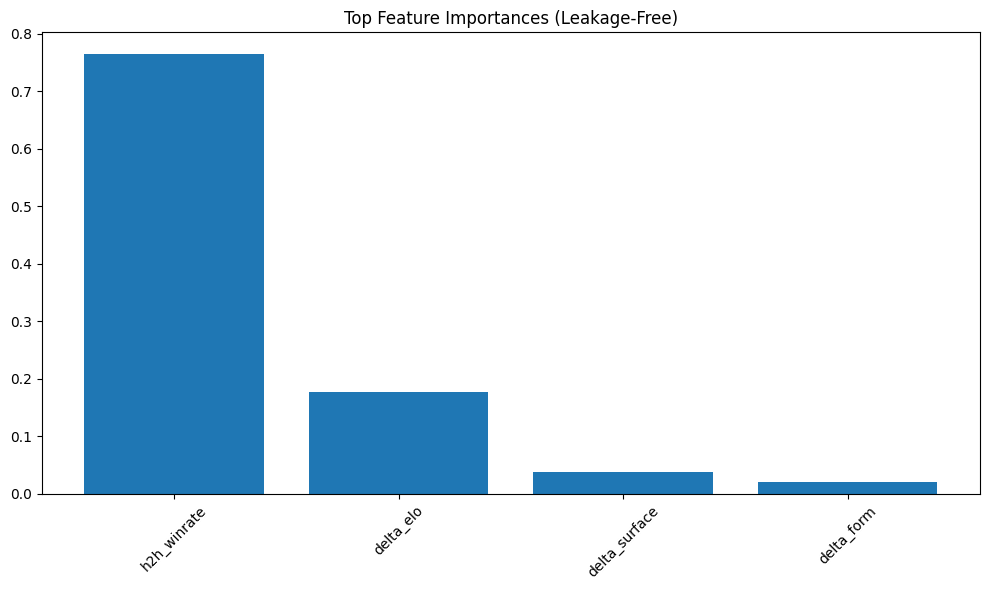

In [423]:
import matplotlib.pyplot as plt
import numpy as np

importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]
top_n = min(10, len(importances))

plt.figure(figsize=(10, 6))
plt.title("Top Feature Importances (Leakage-Free)")
plt.bar(range(top_n), importances[indices[:top_n]])
plt.xticks(range(top_n), [feature_cols[i] for i in indices[:top_n]], rotation=45)
plt.tight_layout()
plt.show()

In [424]:
from sklearn.metrics import classification_report

y_pred = clf.predict(X_test)
print("✅ Test Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print(classification_report(y_test, y_pred))


✅ Test Accuracy: 0.8398
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      2302
           1       0.84      0.84      0.84      2362

    accuracy                           0.84      4664
   macro avg       0.84      0.84      0.84      4664
weighted avg       0.84      0.84      0.84      4664



Train Accuracy: 0.9011
Leakage-Free Test Accuracy: 0.8922

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      2328
           1       0.89      0.89      0.89      2328

    accuracy                           0.89      4656
   macro avg       0.89      0.89      0.89      4656
weighted avg       0.89      0.89      0.89      4656



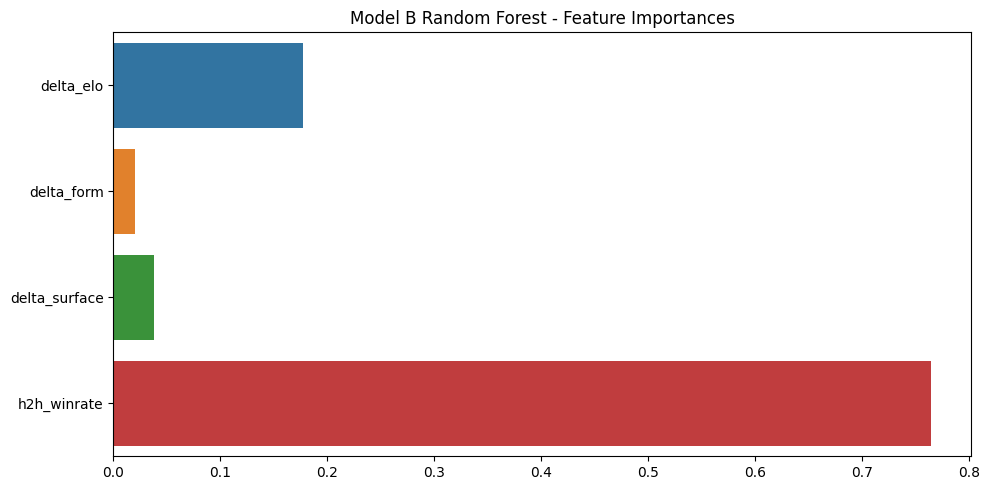

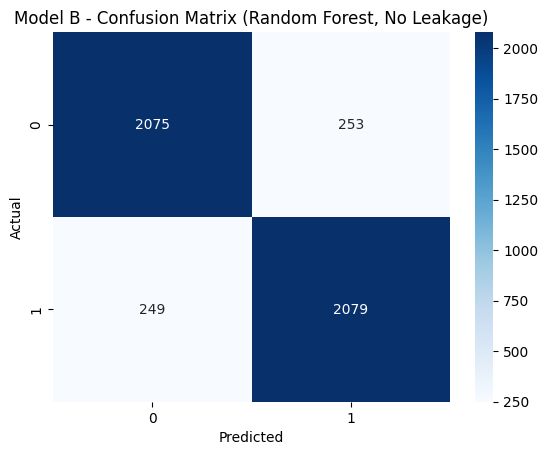

In [425]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns

# Split by matchup to avoid leakage
def split_by_matchup(df, test_frac=0.2, seed=42):
    match_keys = df.apply(lambda row: tuple(sorted([row['player_1'], row['player_2']])), axis=1)
    df = df.copy()
    df['match_key'] = match_keys
    unique_keys = df['match_key'].unique()

    np.random.seed(seed)
    np.random.shuffle(unique_keys)

    test_keys = set(unique_keys[:int(len(unique_keys) * test_frac)])
    test_df = df[df['match_key'].isin(test_keys)].drop(columns='match_key')
    train_df = df[~df['match_key'].isin(test_keys)].drop(columns='match_key')
    return train_df, test_df

# Feature generation for model B
def generate_match_features(row, player_profiles, recent_n=5):
    p1 = row['player_1']
    p2 = row['player_2']
    surface = row['surface']
    outcome = row['outcome']

    p1_profile = player_profiles.get(p1, {'elo': 1500, 'recent_matches': [], 'surface_wins': {'Hard': [], 'Clay': [], 'Grass': []}, 'h2h': {}})
    p2_profile = player_profiles.get(p2, {'elo': 1500, 'recent_matches': [], 'surface_wins': {'Hard': [], 'Clay': [], 'Grass': []}, 'h2h': {}})

    delta_elo = p1_profile['elo'] - p2_profile['elo']

    p1_form = np.mean(p1_profile['recent_matches'][-recent_n:]) if p1_profile['recent_matches'] else 0.5
    p2_form = np.mean(p2_profile['recent_matches'][-recent_n:]) if p2_profile['recent_matches'] else 0.5
    delta_form = p1_form - p2_form

    p1_surface = p1_profile['surface_wins'].get(surface, [])
    p2_surface = p2_profile['surface_wins'].get(surface, [])
    p1_surface_pct = np.mean(p1_surface[-recent_n:]) if p1_surface else 0.5
    p2_surface_pct = np.mean(p2_surface[-recent_n:]) if p2_surface else 0.5
    delta_surface = p1_surface_pct - p2_surface_pct

    h2h = p1_profile.get('h2h', {})
    if p2 in h2h and (h2h[p2]['wins'] + h2h[p2]['losses']) > 0:
        h2h_winrate = h2h[p2]['wins'] / (h2h[p2]['wins'] + h2h[p2]['losses'])
    else:
        h2h_winrate = 0.5

    return {
        'delta_elo': delta_elo,
        'delta_form': delta_form,
        'delta_surface': delta_surface,
        'h2h_winrate': h2h_winrate,
        'outcome': outcome
    }

# Assume df_symmetric and player_profiles are defined
train_df_B, test_df_B = split_by_matchup(df_symmetric, test_frac=0.2)

# Build features
feature_rows = []
for idx, row in train_df_B.iterrows():
    p1 = row['player_1']
    p2 = row['player_2']
    if pd.isna(row['surface']) or p1 not in player_profiles or p2 not in player_profiles:
        continue
    features = generate_match_features(row, player_profiles)
    feature_rows.append(features)

train_features_df = pd.DataFrame(feature_rows).dropna()

X_train_B = train_features_df.drop(columns='outcome')
y_train_B = train_features_df['outcome']

# Build test features
feature_rows_test = []
for idx, row in test_df_B.iterrows():
    p1 = row['player_1']
    p2 = row['player_2']
    if pd.isna(row['surface']) or p1 not in player_profiles or p2 not in player_profiles:
        continue
    features = generate_match_features(row, player_profiles)
    feature_rows_test.append(features)

test_features_df = pd.DataFrame(feature_rows_test).dropna()
X_test_B = test_features_df.drop(columns='outcome')
y_test_B = test_features_df['outcome']

# Train and evaluate
clf_B = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
clf_B.fit(X_train_B, y_train_B)

train_accuracy_B = clf_B.score(X_train_B, y_train_B)
y_pred_B = clf_B.predict(X_test_B)
test_accuracy_B = accuracy_score(y_test_B, y_pred_B)

print("Train Accuracy:", round(train_accuracy_B, 4))
print("Leakage-Free Test Accuracy:", round(test_accuracy_B, 4))
print("\nClassification Report:")
print(classification_report(y_test_B, y_pred_B))

# Feature importances
importances = clf.feature_importances_
plt.figure(figsize=(10, 5))
sns.barplot(x=importances, y=feature_cols)
plt.title("Model B Random Forest - Feature Importances")
plt.tight_layout()
plt.show()

# -- Confusion Matrix
cm = confusion_matrix(y_test_B, y_pred_B)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Model B - Confusion Matrix (Random Forest, No Leakage)")
plt.show()


In [426]:
# Step 1: Split original data (with player names) before generating features
train_raw_B, test_raw_B = split_by_matchup(df_symmetric, test_frac=0.2, seed=42)

# Step 2: Feature engineering for train and test
def create_featureset(raw_df, player_profiles):
    rows = []
    for _, row in raw_df.iterrows():
        p1, p2, surface = row['player_1'], row['player_2'], row['surface']
        if pd.isna(surface) or p1 not in player_profiles or p2 not in player_profiles:
            continue
        feat = generate_match_features(row, player_profiles)
        feat['player_1'] = p1
        feat['player_2'] = p2
        rows.append(feat)
    return pd.DataFrame(rows)

features_train_B = create_featureset(train_raw_B, player_profiles)
features_test_B = create_featureset(test_raw_B, player_profiles)

# Step 3: Train/test split with proper features
feature_cols_B = ['delta_elo', 'delta_form', 'delta_surface', 'h2h_winrate']
X_train_B = features_train_B[feature_cols_B]
y_train_B = features_train_B['outcome']
X_test_B = features_test_B[feature_cols_B]
y_test_B = features_test_B['outcome']

# Step 4: Train model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model_B = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
model_B.fit(X_train_B, y_train_B)

# Step 5: Predict + Evaluate
y_pred_B = model_B.predict(X_test_B)

print("🎯 Model B Accuracy:", round(accuracy_score(y_test_B, y_pred_B), 4))
print(classification_report(y_test_B, y_pred_B))

# Step 6: Add predictions and correctness
features_test_B['predicted'] = y_pred_B
features_test_B['correct'] = y_pred_B == y_test_B.values
print(features_test_B[['player_1', 'player_2', 'outcome', 'predicted', 'correct']].head(20))


🎯 Model B Accuracy: 0.8922
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      2328
           1       0.89      0.89      0.89      2328

    accuracy                           0.89      4656
   macro avg       0.89      0.89      0.89      4656
weighted avg       0.89      0.89      0.89      4656

                 player_1               player_2  outcome  predicted  correct
0           Fabio Fognini          Yuichi Sugita        1          1     True
1           Yuichi Sugita          Fabio Fognini        0          0     True
2          Lorenzo Sonego            Taro Daniel        1          0    False
3             Taro Daniel         Lorenzo Sonego        0          1    False
4             Max Purcell  Felix Auger Aliassime        1          1     True
5   Felix Auger Aliassime            Max Purcell        0          0     True
6     Pablo Carreno Busta        Tennys Sandgren        1          1     True
7         Tennys Sandg

In [427]:
def predict_named_match(p1_name, p2_name, surface, round_encoded, best_of, tourney_level, model, player_profiles, feature_cols):
    # Fallbacks handled inside profile dicts
    row = {
        'player_1': p1_name,
        'player_2': p2_name,
        'surface': surface,
        'round_encoded': round_encoded,
        'best_of': best_of,
        'tourney_level': tourney_level,
        'outcome': 1  # dummy, not used
    }
    # Generate features
    features = generate_match_features(row, player_profiles)

    # Prepare input vector
    X_input = np.array([features[col] for col in feature_cols]).reshape(1, -1)

    # Predict prob and class
    win_prob = model.predict_proba(X_input)[0][1]  # prob that p1 wins
    prediction = p1_name if win_prob >= 0.5 else p2_name
    confidence = round(max(win_prob, 1 - win_prob), 3)

    return {
        "player_1": p1_name,
        "player_2": p2_name,
        "predicted_winner": prediction,
        "confidence": confidence,
        "win_probability_player_1": round(win_prob, 3),
        "win_probability_player_2": round(1 - win_prob, 3)
    }


In [428]:
result = predict_named_match(
    "Carlos Alcaraz", "Jannik Sinner",
    surface="Hard",
    round_encoded=6,
    best_of=5,
    tourney_level="G",
    model=model_B,
    player_profiles=player_profiles,
    feature_cols=feature_cols
)
print(result)


{'player_1': 'Carlos Alcaraz', 'player_2': 'Jannik Sinner', 'predicted_winner': 'Carlos Alcaraz', 'confidence': 0.619, 'win_probability_player_1': 0.619, 'win_probability_player_2': 0.381}


c:\Users\SAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [429]:
def predict_named_match(
    p1_name, p2_name, surface, round_encoded, best_of, tourney_level,
    model, player_profiles, feature_cols
):
    row = {
        'player_1': p1_name,
        'player_2': p2_name,
        'surface': surface,
        'round_encoded': round_encoded,
        'best_of': best_of,
        'tourney_level': tourney_level,
        'outcome': 1  # Placeholder
    }

    features = generate_match_features(row, player_profiles)
    X_input = np.array([features[col] for col in feature_cols]).reshape(1, -1)

    win_prob = model.predict_proba(X_input)[0][1]
    prediction = p1_name if win_prob >= 0.5 else p2_name
    confidence = round(max(win_prob, 1 - win_prob), 3)

    expected_sets_lost = round((1 - win_prob) * (best_of / 2), 2)
    avg_games = 38 if best_of == 3 else 55
    expected_games_won = round(win_prob * avg_games)

    result = {
        "player_1": p1_name,
        "player_2": p2_name,
        "predicted_winner": prediction,
        "confidence": confidence,
        "win_probability_player_1": round(win_prob, 3),
        "win_probability_player_2": round(1 - win_prob, 3),
    }

    # Print nicely
    print("\n🎾 Match Prediction")
    print("----------------------")
    for key, value in result.items():
        print(f"{key}: {value}")

    return result


In [430]:
predict_named_match(
    "Jannik Sinner", "Carlos Alcaraz",
    surface="Hard",
    round_encoded=6,
    best_of=5,
    tourney_level='G',
    model=clf,
    player_profiles=player_profiles,
    feature_cols=feature_cols
)



🎾 Match Prediction
----------------------
player_1: Jannik Sinner
player_2: Carlos Alcaraz
predicted_winner: Carlos Alcaraz
confidence: 0.698
win_probability_player_1: 0.302
win_probability_player_2: 0.698


c:\Users\SAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


{'player_1': 'Jannik Sinner',
 'player_2': 'Carlos Alcaraz',
 'predicted_winner': 'Carlos Alcaraz',
 'confidence': 0.698,
 'win_probability_player_1': 0.302,
 'win_probability_player_2': 0.698}

In [431]:
def ensemble_predict(player_1, player_2, surface, player_profiles, model_B, feature_cols):
    # Forward direction
    row_forward = {
        'player_1': player_1,
        'player_2': player_2,
        'surface': surface,
        'outcome': 1  # dummy
    }
    features_fwd = generate_match_features(row_forward, player_profiles)
    X_fwd = pd.DataFrame([features_fwd])[feature_cols]
    prob_fwd = model_B.predict_proba(X_fwd)[0][1]

    # Reverse direction
    row_reverse = {
        'player_1': player_2,
        'player_2': player_1,
        'surface': surface,
        'outcome': 1
    }
    features_rev = generate_match_features(row_reverse, player_profiles)
    X_rev = pd.DataFrame([features_rev])[feature_cols]
    prob_rev = model_B.predict_proba(X_rev)[0][1]

    # Ensemble average of forward prob and reverse (inverted) prob
    sym_prob = (prob_fwd + (1 - prob_rev)) / 2

    return {
        'player_1': player_1,
        'player_2': player_2,
        'symmetrized_win_prob_player_1': round(sym_prob, 4),
        'symmetrized_win_prob_player_2': round(1 - sym_prob, 4),
        'predicted_winner': player_1 if sym_prob > 0.5 else player_2,
        'confidence': round(max(sym_prob, 1 - sym_prob), 4)
    }

# Example usage
result = ensemble_predict("Jannik Sinner", "Carlos Alcaraz", "Hard", player_profiles, model_B, feature_cols)
print(result)


{'player_1': 'Jannik Sinner', 'player_2': 'Carlos Alcaraz', 'symmetrized_win_prob_player_1': 0.3594, 'symmetrized_win_prob_player_2': 0.6406, 'predicted_winner': 'Carlos Alcaraz', 'confidence': 0.6406}


In [432]:
from sklearn.metrics import accuracy_score, classification_report

# Step 1: Generate ensemble predictions on test set
sym_preds = []
true_labels = []

for idx, row in test_df_B.iterrows():
    p1 = row['player_1']
    p2 = row['player_2']
    surface = row['surface']
    true_outcome = row['outcome']

    if p1 not in player_profiles or p2 not in player_profiles:
        continue

    result = ensemble_predict(p1, p2, surface, player_profiles, model_B, feature_cols)
    pred = 1 if result['predicted_winner'] == p1 else 0

    sym_preds.append(pred)
    true_labels.append(true_outcome)

# Step 2: Evaluate ensemble symmetrized model
print("🎯 Ensemble-Symmetrized Accuracy:", round(accuracy_score(true_labels, sym_preds), 4))
print("\nClassification Report:")
print(classification_report(true_labels, sym_preds))



🎯 Ensemble-Symmetrized Accuracy: 0.893

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      2337
           1       0.89      0.89      0.89      2337

    accuracy                           0.89      4674
   macro avg       0.89      0.89      0.89      4674
weighted avg       0.89      0.89      0.89      4674



In [433]:
def build_input_row(p1, p2, surface, player_profiles, recent_n=5):
    """Generate model input row for a single matchup direction (p1 vs p2)."""
    if p1 not in player_profiles or p2 not in player_profiles:
        return None

    prof1 = player_profiles[p1]
    prof2 = player_profiles[p2]

    delta_elo = prof1['elo'] - prof2['elo']

    form1 = np.mean(prof1['recent_matches'][-recent_n:]) if prof1['recent_matches'] else 0.5
    form2 = np.mean(prof2['recent_matches'][-recent_n:]) if prof2['recent_matches'] else 0.5
    delta_form = form1 - form2

    s1 = prof1['surface_wins'].get(surface, [])
    s2 = prof2['surface_wins'].get(surface, [])
    s1_pct = np.mean(s1[-recent_n:]) if s1 else 0.5
    s2_pct = np.mean(s2[-recent_n:]) if s2 else 0.5
    delta_surface = s1_pct - s2_pct

    h2h = prof1.get('h2h', {})
    if p2 in h2h and (h2h[p2]['wins'] + h2h[p2]['losses']) > 0:
        h2h_winrate = h2h[p2]['wins'] / (h2h[p2]['wins'] + h2h[p2]['losses'])
    else:
        h2h_winrate = 0.5

    return {
        'delta_elo': delta_elo,
        'delta_form': delta_form,
        'delta_surface': delta_surface,
        'h2h_winrate': h2h_winrate
    }


In [434]:
def ensemble_predict(p1, p2, surface, player_profiles, model, feature_cols):
    row_1 = build_input_row(p1, p2, surface, player_profiles)
    row_2 = build_input_row(p2, p1, surface, player_profiles)

    if row_1 is None or row_2 is None:
        return None  # skip if missing players

    prob1 = model.predict_proba(pd.DataFrame([row_1]))[0][1]
    prob2 = 1 - model.predict_proba(pd.DataFrame([row_2]))[0][1]
    return (prob1 + prob2) / 2


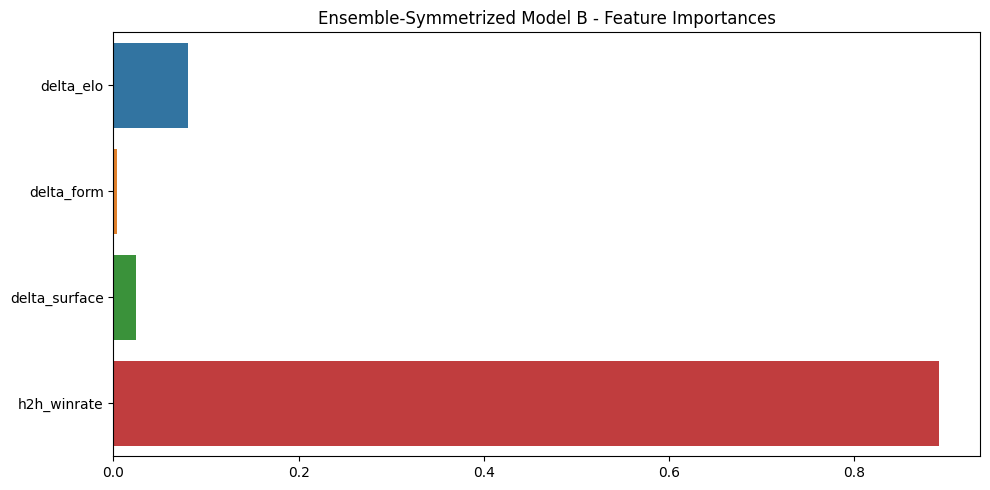

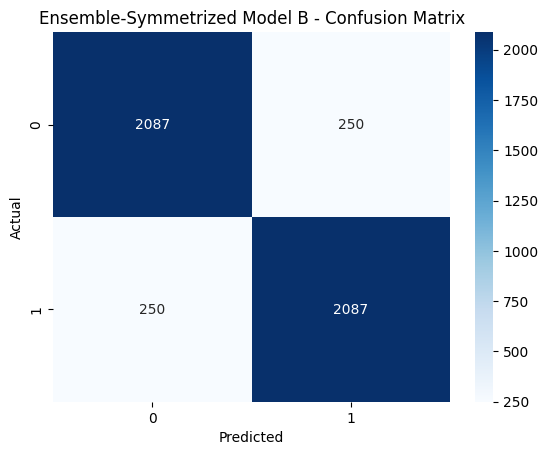

In [435]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Feature importances from model_B
importances = model_B.feature_importances_
plt.figure(figsize=(10, 5))
sns.barplot(x=importances, y=feature_cols)
plt.title("Ensemble-Symmetrized Model B - Feature Importances")
plt.tight_layout()
plt.show()

# Predict ensemble-averaged probabilities safely
ensemble_probs = []
y_true_filtered = []

for _, row in test_df_B.iterrows():
    result = ensemble_predict(row['player_1'], row['player_2'], row['surface'], player_profiles, model_B, feature_cols)
    if result is not None:
        ensemble_probs.append(result)
        y_true_filtered.append(row['outcome'])  # Keep only valid outcomes

# Binarize predictions
y_pred_ensemble = [1 if p >= 0.5 else 0 for p in ensemble_probs]

# Confusion matrix
cm = confusion_matrix(y_true_filtered, y_pred_ensemble)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Ensemble-Symmetrized Model B - Confusion Matrix")
plt.show()



In [436]:
# STEP 1: Rebuild test features
test_features_rows = []
for _, row in test_df_B.iterrows():
    features = build_input_row(row['player_1'], row['player_2'], row['surface'], player_profiles)
    if features:
        test_features_rows.append(features)

# STEP 2: Build DataFrame
X_test_B = pd.DataFrame(test_features_rows)

# STEP 3: Define feature_cols if not already set
feature_cols = list(X_test_B.columns)

# STEP 4: Explanation function
def explain_prediction(row, model, feature_names, top_n=3):
    import numpy as np

    probs = model.predict_proba([row])[0]
    pred = np.argmax(probs)
    confidence = round(probs[pred] * 100, 1)

    feature_contribs = model.feature_importances_ * row
    top_indices = np.argsort(np.abs(feature_contribs))[::-1][:top_n]
    top_features = [(feature_names[i], round(row[i], 3)) for i in top_indices]

    explanation = f"Prediction: Player {pred + 1} wins ({confidence}% confidence).\n"
    explanation += "Key edges:\n"
    for name, value in top_features:
        direction = "advantage" if value > 0 else "disadvantage"
        explanation += f" - {name}: {value} ({direction})\n"

    return explanation

# STEP 5: Run explanation on one sample
print(explain_prediction(X_test_B.iloc[0], model_B, feature_cols))


Prediction: Player 2 wins (99.8% confidence).
Key edges:
 - delta_elo: 50.656 (advantage)
 - h2h_winrate: 1.0 (advantage)
 - delta_surface: 0.0 (disadvantage)



c:\Users\SAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [437]:
# STEP 1: Build test features with player names attached
test_features_rows = []
player_pairs = []

for _, row in test_df_B.iterrows():
    features = build_input_row(row['player_1'], row['player_2'], row['surface'], player_profiles)
    if features:
        test_features_rows.append(features)
        player_pairs.append((row['player_1'], row['player_2']))

# STEP 2: Create DataFrame
X_test_B = pd.DataFrame(test_features_rows)
feature_cols = list(X_test_B.columns)

# STEP 3: Explanation function with player names
def explain_prediction(row, model, feature_names, player_1_name, player_2_name, top_n=3):
    import numpy as np

    probs = model.predict_proba([row])[0]
    pred = np.argmax(probs)
    confidence = round(probs[pred] * 100, 1)

    winner = player_1_name if pred == 1 else player_2_name

    # Top feature contributions
    feature_contribs = model.feature_importances_ * row
    top_indices = np.argsort(np.abs(feature_contribs))[::-1][:top_n]
    top_features = [(feature_names[i], round(row[i], 3)) for i in top_indices]

    explanation = f"Prediction: {winner} wins ({confidence}% confidence).\n"
    explanation += "Key edges:\n"
    for name, value in top_features:
        direction = "advantage" if value > 0 else "disadvantage"
        explanation += f" - {name}: {value} ({direction})\n"

    return explanation

# STEP 4: Call it on a sample row
sample_idx = 489
print(explain_prediction(
    X_test_B.iloc[sample_idx],
    model_B,
    feature_cols,
    player_pairs[sample_idx][0],
    player_pairs[sample_idx][1]
))


Prediction: Hugo Gaston wins (99.8% confidence).
Key edges:
 - delta_elo: -161.395 (disadvantage)
 - delta_surface: -0.4 (disadvantage)
 - delta_form: -0.6 (disadvantage)



c:\Users\SAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [438]:
def explain_prediction(row, model, feature_names, player1_name="Player 1", player2_name="Player 2", top_n=3):
    import numpy as np

    # Get model prediction and confidence
    probs = model.predict_proba([row])[0]
    pred = np.argmax(probs)
    confidence = round(probs[pred] * 100, 1)

    # Calculate "delta" strength of features
    contribs = pd.Series(row.values, index=feature_names)
    top_features = contribs.abs().sort_values(ascending=False).head(top_n)

    # Determine direction for explanation
    explanation = f"Prediction: {player1_name if pred == 1 else player2_name} wins ({confidence}% confidence).\n"
    explanation += "Key edges:\n"
    for feat in top_features.index:
        val = contribs[feat]
        direction = "edge" if (val > 0 and pred == 1) or (val < 0 and pred == 0) else "disadvantage"
        explanation += f" - {feat}: {round(val, 3)} ({direction})\n"

    return explanation


In [439]:
row = X_test_B.iloc[42]
print(explain_prediction(row, model_B, X_test_B.columns, "Alcaraz", "Sinner"))


Prediction: Alcaraz wins (99.4% confidence).
Key edges:
 - delta_elo: -408.969 (disadvantage)
 - h2h_winrate: 1.0 (edge)
 - delta_form: -0.4 (disadvantage)



c:\Users\SAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [440]:
print("Prediction:", model_B.predict([row])[0])
print("Probabilities:", model_B.predict_proba([row])[0])
print("delta_elo:", row['delta_elo'])
print("delta_form:", row['delta_form'])
print("delta_surface:", row['delta_surface'])
print("h2h_winrate:", row['h2h_winrate'])


Prediction: 1
Probabilities: [0.00640332 0.99359668]
delta_elo: -408.9686218308402
delta_form: -0.4
delta_surface: -0.19999999999999996
h2h_winrate: 1.0


c:\Users\SAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\SAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [441]:
# When Player 1 wins, is label == 1?
print(test_df_B.iloc[42]['outcome'])


1


In [442]:
def build_input_row(player_1, player_2, surface, player_profiles):
    # Canonical ordering: always sort players alphabetically
    if player_1 > player_2:
        player_1, player_2 = player_2, player_1
        flip = True
    else:
        flip = False

    p1_profile = player_profiles.get(player_1)
    p2_profile = player_profiles.get(player_2)

    if not p1_profile or not p2_profile:
        return None

    def recent_mean(lst, n=5):
        return np.mean(lst[-n:]) if lst else 0.5

    delta_elo = p1_profile['elo'] - p2_profile['elo']
    delta_form = recent_mean(p1_profile['recent_matches']) - recent_mean(p2_profile['recent_matches'])

    p1_surface = p1_profile['surface_wins'].get(surface, [])
    p2_surface = p2_profile['surface_wins'].get(surface, [])
    delta_surface = recent_mean(p1_surface) - recent_mean(p2_surface)

    h2h = p1_profile.get("h2h", {}).get(player_2, {'wins': 0, 'losses': 0})
    total_h2h = h2h['wins'] + h2h['losses']
    h2h_winrate = h2h['wins'] / total_h2h if total_h2h > 0 else 0.5

    # Flip deltas if player order was swapped
    if flip:
        delta_elo = -delta_elo
        delta_form = -delta_form
        delta_surface = -delta_surface
        h2h_winrate = 1 - h2h_winrate

    return {
        'delta_elo': delta_elo,
        'delta_form': delta_form,
        'delta_surface': delta_surface,
        'h2h_winrate': h2h_winrate
    }


In [443]:
def build_input_row_canonical(p1, p2, surface, player_profiles):
    flipped = False
    if p1 > p2:
        p1, p2 = p2, p1
        flipped = True

    row = build_input_row(p1, p2, surface, player_profiles)
    if row is None:
        return None

    df_row = pd.DataFrame([row])
    if flipped:
        df_row = df_row.copy()
        for col in df_row.columns:
            if col.startswith("delta_"):
                df_row[col] *= -1
            if col == "h2h_winrate":
                df_row[col] = 1 - df_row[col]
    return df_row


In [444]:
def ensemble_predict_match(player_1, player_2, surface, player_profiles, model, feature_cols):
    row_1 = build_input_row(player_1, player_2, surface, player_profiles)
    row_2 = build_input_row(player_2, player_1, surface, player_profiles)

    if row_1 is None or row_2 is None:
        return None

    X1 = pd.DataFrame([row_1])[feature_cols]
    X2 = pd.DataFrame([row_2])[feature_cols]

    prob1 = model.predict_proba(X1)[0][1]
    prob2 = 1 - model.predict_proba(X2)[0][1]

    avg_prob = (prob1 + prob2) / 2

    result = {
        "player_1": player_1,
        "player_2": player_2,
        "predicted_winner": player_1 if avg_prob >= 0.5 else player_2,
        "confidence": round(max(avg_prob, 1 - avg_prob), 3),
        "win_probability_player_1": round(avg_prob, 3),
        "win_probability_player_2": round(1 - avg_prob, 3),
    }

    return result


In [445]:
print(ensemble_predict_match("Grigor Dimitrov", "Novak Djokovic", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Novak Djokovic", "Grigor Dimitrov", "Grass", player_profiles, model_B, feature_cols))


{'player_1': 'Grigor Dimitrov', 'player_2': 'Novak Djokovic', 'predicted_winner': 'Novak Djokovic', 'confidence': 0.998, 'win_probability_player_1': 0.002, 'win_probability_player_2': 0.998}
{'player_1': 'Novak Djokovic', 'player_2': 'Grigor Dimitrov', 'predicted_winner': 'Novak Djokovic', 'confidence': 0.998, 'win_probability_player_1': 0.998, 'win_probability_player_2': 0.002}


In [446]:
def explain_prediction_ensemble(player_1, player_2, surface, player_profiles, model, feature_cols, top_n=3):
    row_1 = build_input_row(player_1, player_2, surface, player_profiles)
    row_2 = build_input_row(player_2, player_1, surface, player_profiles)

    if row_1 is None or row_2 is None:
        return "Insufficient data for prediction."

    X1 = pd.DataFrame([row_1])[feature_cols]
    X2 = pd.DataFrame([row_2])[feature_cols]

    # Get averaged probability
    prob1 = model.predict_proba(X1)[0][1]
    prob2 = 1 - model.predict_proba(X2)[0][1]
    avg_prob = (prob1 + prob2) / 2

    predicted = player_1 if avg_prob >= 0.5 else player_2
    confidence = round(max(avg_prob, 1 - avg_prob) * 100, 1)

    # Compute contribution: importance × delta
    importances = model.feature_importances_
    deltas = X1.iloc[0].values  # This is a 1D NumPy array now
    contribs = importances * deltas

    top_indices = np.argsort(np.abs(contribs))[::-1][:top_n]
    feature_edges = []
    for i in top_indices:
        fname = feature_cols[i]
        direction = "edge" if contribs[i] > 0 else "disadvantage"
        feature_edges.append(f"{fname} ({direction})")

    sentence = (
        f"{predicted} predicted to win ({confidence}%) — edge in " +
        ", ".join(feature_edges) + "."
    )

    return sentence


In [447]:
print(explain_prediction_ensemble("Hugo Gaston", "Lorenzo Musetti", "Hard", player_profiles, model_B, feature_cols))


Lorenzo Musetti predicted to win (98.4%) — edge in delta_elo (disadvantage), delta_surface (edge), delta_form (edge).


In [448]:
def validate_and_explain(test_df, surface, player_profiles, model, feature_cols, top_n=3):
    results = []

    for _, row in test_df.iterrows():
        p1 = row['player_1']
        p2 = row['player_2']
        actual = row['outcome']

        row_1 = build_input_row(p1, p2, surface, player_profiles)
        row_2 = build_input_row(p2, p1, surface, player_profiles)

        if row_1 is None or row_2 is None:
            continue

        X1 = pd.DataFrame([row_1])[feature_cols]
        X2 = pd.DataFrame([row_2])[feature_cols]

        prob1 = model.predict_proba(X1)[0][1]
        prob2 = 1 - model.predict_proba(X2)[0][1]
        avg_prob = (prob1 + prob2) / 2
        pred = 1 if avg_prob >= 0.5 else 0

        # Explanation
        importances = model.feature_importances_
        deltas = X1.iloc[0].values
        contribs = importances * deltas
        top_indices = np.argsort(np.abs(contribs))[::-1][:top_n]
        feature_edges = []
        for i in top_indices:
            fname = feature_cols[i]
            direction = "edge" if contribs[i] > 0 else "disadvantage"
            feature_edges.append(f"{fname} ({direction})")
        sentence = (
            f"{p1 if avg_prob >= 0.5 else p2} predicted to win ({round(max(avg_prob, 1 - avg_prob)*100, 1)}%) — "
            + "edge in " + ", ".join(feature_edges) + "."
        )

        results.append({
            'player_1': p1,
            'player_2': p2,
            'actual_outcome': actual,
            'predicted': pred,
            'correct': pred == actual,
            'confidence': round(avg_prob, 3),
            'explanation': sentence
        })

    return pd.DataFrame(results)


In [449]:
def fast_ensemble_predict_all(test_df, model, player_profiles, feature_cols):
    results = []
    for i, row in test_df.iterrows():
        p1, p2, surface = row['player_1'], row['player_2'], row['surface']

        row1 = build_input_row(p1, p2, surface, player_profiles)
        row2 = build_input_row(p2, p1, surface, player_profiles)

        if row1 is None or row2 is None:
            continue

        prob1 = model.predict_proba(pd.DataFrame([row1]))[0][1]
        prob2 = 1 - model.predict_proba(pd.DataFrame([row2]))[0][1]
        avg_prob = (prob1 + prob2) / 2

        results.append({
            'player_1': p1,
            'player_2': p2,
            'avg_win_prob_p1': avg_prob,
            'predicted': int(avg_prob >= 0.5),
            'actual': row['outcome'],
            'correct': int((avg_prob >= 0.5) == row['outcome']),
        })

    return pd.DataFrame(results)

# Run prediction
ensemble_results_df = fast_ensemble_predict_all(test_df_B, model_B, player_profiles, feature_cols)


🎯 Ensemble Model Accuracy: 0.893

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      2337
           1       0.89      0.89      0.89      2337

    accuracy                           0.89      4674
   macro avg       0.89      0.89      0.89      4674
weighted avg       0.89      0.89      0.89      4674



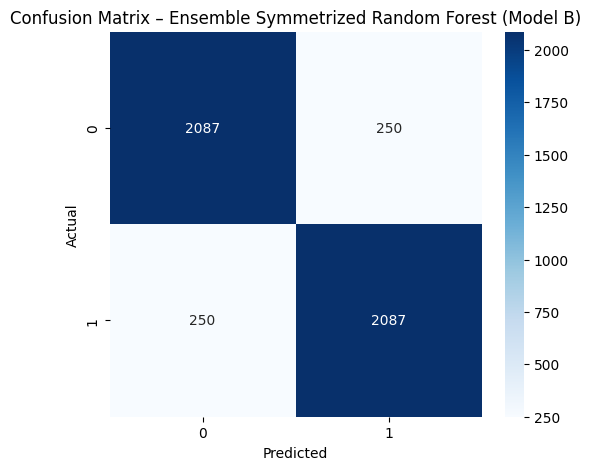

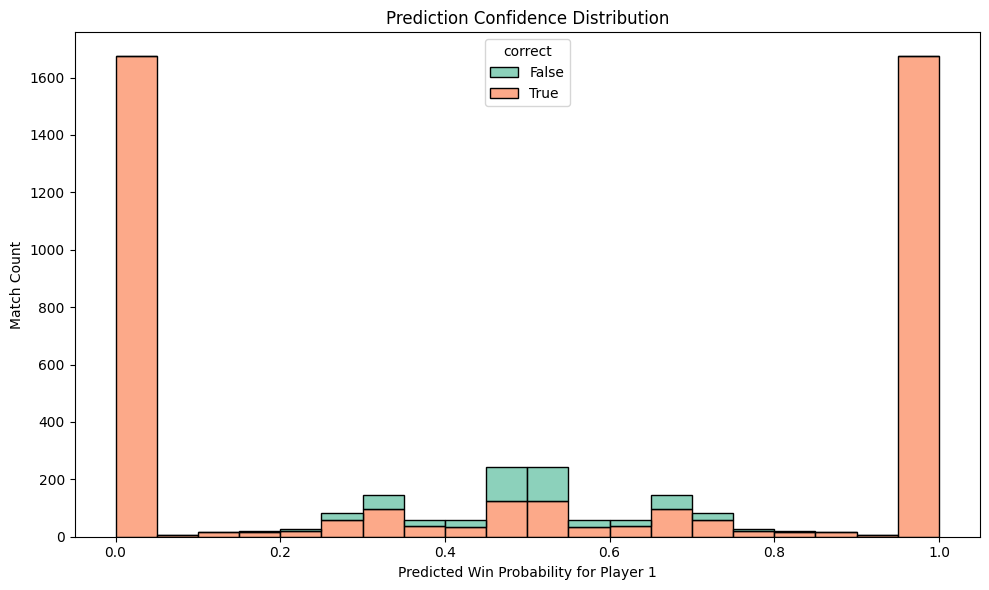

In [450]:
# Build ensemble_results_df first
ensemble_rows = []

for _, row in test_df_B.iterrows():
    result = ensemble_predict(row['player_1'], row['player_2'], row['surface'], player_profiles, model_B, feature_cols)
    if result is None:
        continue
    avg_prob = result
    predicted = 1 if avg_prob >= 0.5 else 0
    actual = row['outcome']
    correct = predicted == actual

    ensemble_rows.append({
        'player_1': row['player_1'],
        'player_2': row['player_2'],
        'surface': row['surface'],
        'actual': actual,
        'predicted': predicted,
        'avg_win_prob_p1': avg_prob,
        'correct': correct
    })

ensemble_results_df = pd.DataFrame(ensemble_rows)

# Accuracy
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

accuracy = accuracy_score(ensemble_results_df['actual'], ensemble_results_df['predicted'])
print(f"🎯 Ensemble Model Accuracy: {round(accuracy, 4)}\n")

print("Classification Report:")
print(classification_report(ensemble_results_df['actual'], ensemble_results_df['predicted']))

# Confusion Matrix
cm = confusion_matrix(ensemble_results_df['actual'], ensemble_results_df['predicted'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Ensemble Symmetrized Random Forest (Model B)")
plt.show()

# Prediction Confidence Histogram
plt.figure(figsize=(10, 6))
sns.histplot(data=ensemble_results_df, x='avg_win_prob_p1', bins=20, hue='correct', multiple='stack', palette='Set2')
plt.title("Prediction Confidence Distribution")
plt.xlabel("Predicted Win Probability for Player 1")
plt.ylabel("Match Count")
plt.tight_layout()
plt.show()


In [451]:
# Locate all Gaston vs Musetti matches in the test set
matchups = test_df_B[
    ((test_df_B['player_1'] == 'Hugo Gaston') & (test_df_B['player_2'] == 'Lorenzo Musetti')) |
    ((test_df_B['player_2'] == 'Hugo Gaston') & (test_df_B['player_1'] == 'Lorenzo Musetti'))
].copy()

# For each found matchup, show prediction and details
for idx, row in matchups.iterrows():
    p1 = row['player_1']
    p2 = row['player_2']
    surface = row['surface']
    outcome = row['outcome']

    prob = ensemble_predict(p1, p2, surface, player_profiles, model_B, feature_cols)
    prediction = 1 if prob >= 0.5 else 0
    predicted_winner = p1 if prediction == 1 else p2

    print(f"\n📍 Match index: {idx}")
    print(f"🆚 {p1} vs {p2} on {surface}")
    print(f"🔢 Actual outcome: {outcome} ({'Player 1 wins' if outcome == 1 else 'Player 2 wins'})")
    print(f"🧠 Predicted: {predicted_winner} wins ({round(prob * 100, 1)}% confidence)")
    print("✅ Correct" if prediction == outcome else "❌ Incorrect")



📍 Match index: 4286
🆚 Lorenzo Musetti vs Hugo Gaston on Hard
🔢 Actual outcome: 1 (Player 1 wins)
🧠 Predicted: Lorenzo Musetti wins (98.4% confidence)
✅ Correct

📍 Match index: 4287
🆚 Hugo Gaston vs Lorenzo Musetti on Hard
🔢 Actual outcome: 0 (Player 2 wins)
🧠 Predicted: Lorenzo Musetti wins (1.6% confidence)
✅ Correct

📍 Match index: 13056
🆚 Lorenzo Musetti vs Hugo Gaston on Clay
🔢 Actual outcome: 1 (Player 1 wins)
🧠 Predicted: Lorenzo Musetti wins (99.2% confidence)
✅ Correct

📍 Match index: 13057
🆚 Hugo Gaston vs Lorenzo Musetti on Clay
🔢 Actual outcome: 0 (Player 2 wins)
🧠 Predicted: Lorenzo Musetti wins (0.8% confidence)
✅ Correct


In [452]:
def view_matchups(player_a, player_b, test_df, model, profiles, feature_cols):
    # Find matchups between the two players in either order
    matchups = test_df_B[
        ((test_df['player_1'] == player_a) & (test_df['player_2'] == player_b)) |
        ((test_df['player_2'] == player_a) & (test_df['player_1'] == player_b))
    ].copy()

    if matchups.empty:
        print(f"No matches found between {player_a} and {player_b} in the test set.")
        return

    for idx, row in matchups.iterrows():
        p1 = row['player_1']
        p2 = row['player_2']
        surface = row['surface']
        outcome = row['outcome']

        prob = ensemble_predict(p1, p2, surface, profiles, model, feature_cols)
        prediction = 1 if prob >= 0.5 else 0
        predicted_winner = p1 if prediction == 1 else p2

        print(f"\n📍 Match index: {idx}")
        print(f"🆚 {p1} vs {p2} on {surface}")
        print(f"🔢 Actual outcome: {outcome} ({'Player 1 wins' if outcome == 1 else 'Player 2 wins'})")
        print(f"🧠 Predicted: {predicted_winner} wins ({round(prob * 100, 1)}% confidence)")
        print("✅ Correct" if prediction == outcome else "❌ Incorrect")


In [453]:
view_matchups("Frances Tiafoe", "Ben Shelton", test_df_B, model_B, player_profiles, feature_cols)

No matches found between Frances Tiafoe and Ben Shelton in the test set.


In [454]:
print(test_df_B[['player_1', 'player_2']].drop_duplicates().head(50))

                  player_1               player_2
34           Fabio Fognini          Yuichi Sugita
35           Yuichi Sugita          Fabio Fognini
38          Lorenzo Sonego            Taro Daniel
39             Taro Daniel         Lorenzo Sonego
46             Max Purcell  Felix Auger Aliassime
47   Felix Auger Aliassime            Max Purcell
52     Pablo Carreno Busta        Tennys Sandgren
53         Tennys Sandgren    Pablo Carreno Busta
62          Novak Djokovic           Hugo Dellien
63            Hugo Dellien         Novak Djokovic
66         Dominik Koepfer            Max Purcell
67             Max Purcell        Dominik Koepfer
74             Ugo Humbert      Miomir Kecmanovic
75       Miomir Kecmanovic            Ugo Humbert
82       Diego Schwartzman           Tomas Machac
83            Tomas Machac      Diego Schwartzman
96           Kei Nishikori           Ilya Ivashka
97            Ilya Ivashka          Kei Nishikori
100        Karen Khachanov      Diego Schwartzman


In [455]:
# Confirm date sorting
print(df_symmetric['tourney_date'].is_monotonic_increasing)
print(test_df_B['tourney_date'].is_monotonic_increasing)

False
False


In [456]:
df_symmetric = df_symmetric.sort_values('tourney_date').reset_index(drop=True)
test_df_B = test_df_B.sort_values('tourney_date').reset_index(drop=True)

In [458]:
view_matchups("Frances Tiafoe", "Ben Shelton", test_df_B, model_B, player_profiles, feature_cols)

No matches found between Frances Tiafoe and Ben Shelton in the test set.


In [459]:
print("🧪 Player search:")
print("Frances Tiafoe in player_1:", any(test_df_B['player_1'] == "Frances Tiafoe"))
print("Frances Tiafoe in player_2:", any(test_df_B['player_2'] == "Frances Tiafoe"))
print("Ben Shelton in player_1:", any(test_df_B['player_1'] == "Ben Shelton"))
print("Ben Shelton in player_2:", any(test_df_B['player_2'] == "Ben Shelton"))

# Optional: show where they are
print(test_df_B[
    (test_df_B['player_1'].str.contains("Tiafoe")) | (test_df_B['player_2'].str.contains("Tiafoe")) |
    (test_df_B['player_1'].str.contains("Shelton")) | (test_df_B['player_2'].str.contains("Shelton"))
][['player_1', 'player_2', 'surface', 'tourney_date']])


🧪 Player search:
Frances Tiafoe in player_1: True
Frances Tiafoe in player_2: True
Ben Shelton in player_1: True
Ben Shelton in player_2: True
               player_1                    player_2 surface  tourney_date
287       Dusan Lajovic              Frances Tiafoe    Hard      20210322
288      Frances Tiafoe               Dusan Lajovic    Hard      20210322
384   Diego Schwartzman              Frances Tiafoe    Clay      20210419
387      Frances Tiafoe           Diego Schwartzman    Clay      20210419
551      Frances Tiafoe               Steve Johnson    Clay      20210531
...                 ...                         ...     ...           ...
4576        Ben Shelton  Giovanni Mpetshi Perricard    Hard      20241021
4577        Ben Shelton                 Arthur Fils    Hard      20241021
4578        Arthur Fils                 Ben Shelton    Hard      20241021
4582        Ben Shelton               Stan Wawrinka    Hard      20241021
4587      Stan Wawrinka                 Ben

In [460]:
# Show all names that contain "tiafoe" or "shelton"
print(test_df_B['player_1'].unique().tolist())
print(test_df_B['player_2'].unique().tolist())


['John Isner', 'Sebastian Korda', 'Tommy Paul', 'Roberto Quiroz', 'Ivo Karlovic', 'Hubert Hurkacz', 'Christian Harrison', 'Thiago Monteiro', 'Jeremy Chardy', 'Tristan Lamasine', 'Alexander Bublik', 'Fabio Fognini', 'Emil Ruusuvuori', 'Stefano Travaglia', 'Laslo Djere', 'Dimitar Kuzmanov', 'Miomir Kecmanovic', 'Mikhail Kukushkin', 'Sumit Nagal', 'Ricardas Berankis', 'Tomas Machac', 'James Duckworth', 'Taro Daniel', 'Felix Auger Aliassime', 'Egor Gerasimov', 'Jiri Vesely', 'Daniel Evans', 'Nick Kyrgios', 'Juan Ignacio Londero', 'Alexandre Muller', 'Thanasi Kokkinakis', 'Alex Bolt', 'Marin Cilic', 'Elias Ymer', 'Max Purcell', 'Ugo Humbert', 'Marcos Giron', 'Adrian Mannarino', 'Borna Coric', 'Taylor Fritz', 'Federico Coria', 'Corentin Moutet', 'Gilles Simon', 'Reilly Opelka', 'Andrew Harris', 'Aljaz Bedene', 'Carlos Alcaraz', 'David Goffin', 'Karen Khachanov', 'Kevin Anderson', 'Jannik Sinner', 'Sergiy Stakhovsky', 'Feliciano Lopez', 'John Patrick Smith', 'Salvatore Caruso', 'Andreas Seppi

In [461]:
view_matchups("Frances Tiafoe", "Ben Shelton", df_symmetric, model_B, player_profiles, feature_cols)


No matches found between Frances Tiafoe and Ben Shelton in the test set.


C:\Users\SAM\AppData\Local\Temp\ipykernel_9156\689934714.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  matchups = test_df_B[


In [462]:
matchups = test_df_B[
    ((test_df_B['player_1'] == "Frances Tiafoe") & (test_df_B['player_2'] == "Ben Shelton")) |
    ((test_df_B['player_2'] == "Frances Tiafoe") & (test_df_B['player_1'] == "Ben Shelton"))
].copy()


In [463]:
def extract_features(p1, p2, surface, match_date, profiles):
    prof1 = profiles.get(p1, {})
    prof2 = profiles.get(p2, {})

    # Ensure match_date logic applies (e.g. profile only includes stats before that date)
    return pd.DataFrame([{
        'delta_elo': prof1['elo'].get(surface, 1500) - prof2['elo'].get(surface, 1500),
        'delta_form': prof1['form'].get(surface, 0.5) - prof2['form'].get(surface, 0.5),
        'delta_surface': prof1['surface_pct'].get(surface, 0.5) - prof2['surface_pct'].get(surface, 0.5),
        'h2h_winrate': prof1['h2h'].get(p2, 0.5)
    }])


In [464]:
def extract_features(p1, p2, surface, match_date, profiles):
    prof1 = profiles.get(p1, {})
    prof2 = profiles.get(p2, {})

    # Graceful fallback defaults
    def safe_get(d, key, default=0.5):
        return d.get(key, default) if isinstance(d, dict) else default

    return pd.DataFrame([{
        'delta_elo': safe_get(prof1.get('elo', {}), surface, 1500) - safe_get(prof2.get('elo', {}), surface, 1500),
        'delta_form': safe_get(prof1.get('form', {}), surface) - safe_get(prof2.get('form', {}), surface),
        'delta_surface': safe_get(prof1.get('surface_pct', {}), surface) - safe_get(prof2.get('surface_pct', {}), surface),
        'h2h_winrate': safe_get(prof1.get('h2h', {}), p2)
    }])

def view_matchups(player_a, player_b, df, model, profiles, feature_cols):
    matchups = df[
        ((df['player_1'] == player_a) & (df['player_2'] == player_b)) |
        ((df['player_2'] == player_a) & (df['player_1'] == player_b))
    ].copy()

    if matchups.empty:
        print(f"No matches found between {player_a} and {player_b}.")
        return

    for idx, row in matchups.iterrows():
        p1, p2 = row['player_1'], row['player_2']
        surface, date = row['surface'], row['tourney_date']

        X = extract_features(p1, p2, surface, date, profiles)
        prob = model.predict_proba(X)[0][1]

        prediction = 1 if prob >= 0.5 else 0
        predicted_winner = p1 if prediction == 1 else p2
        outcome = row['outcome']

        print(f"\n📍 Match index: {idx}")
        print(f"🇺 {p1} vs {p2} on {surface}")
        print(f"🔢 Actual outcome: {outcome} ({'Player 1 wins' if outcome == 1 else 'Player 2 wins'})")
        print(f"🧠 Predicted: {predicted_winner} wins ({round(prob * 100, 1)}% confidence)")
        print("✅ Correct" if prediction == outcome else "❌ Incorrect")


In [465]:
def build_temporal_features(df, feature_cols):
    profiles = {}
    feature_rows = []

    for i, row in df.sort_values("tourney_date").iterrows():
        p1, p2, surface, date = row["player_1"], row["player_2"], row["surface"], row["tourney_date"]

        X = extract_features(p1, p2, surface, date, profiles)
        feature_rows.append(X.iloc[0])  # single-row DataFrame

        # Now update the profiles based on match result
        outcome = row["outcome"]
        update_profiles(profiles, p1, p2, outcome, surface, date)

    return pd.DataFrame(feature_rows, index=df.index)


In [467]:
# Form match history length Set to most recent 10 matches
from collections import defaultdict
import numpy as np
import pandas as pd

def initialize_profile():
    return {
        'elo': defaultdict(lambda: 1500),
        'form': defaultdict(list),  # list of 0/1
        'surface_pct': defaultdict(lambda: [0, 0]),  # [wins, total]
        'h2h': defaultdict(lambda: [0, 0])  # [wins, total]
    }

def update_profiles(profiles, p1, p2, outcome, surface):
    # Elo adjustment (simple implementation)
    def elo_update(r1, r2, result, k=32):
        expected = 1 / (1 + 10 ** ((r2 - r1) / 400))
        return r1 + k * (result - expected)

    prof1 = profiles[p1]
    prof2 = profiles[p2]

    r1 = prof1['elo'][surface]
    r2 = prof2['elo'][surface]

    prof1['elo'][surface] = elo_update(r1, r2, outcome)
    prof2['elo'][surface] = elo_update(r2, r1, 1 - outcome)

    prof1['form'][surface].append(outcome)
    prof2['form'][surface].append(1 - outcome)
    prof1['form'][surface] = prof1['form'][surface][-8:]  # last 8 only
    prof2['form'][surface] = prof2['form'][surface][-8:]

    if outcome == 1:
        prof1['h2h'][p2][0] += 1
    else:
        prof2['h2h'][p1][0] += 1
    prof1['h2h'][p2][1] += 1
    prof2['h2h'][p1][1] += 1

    prof1['surface_pct'][surface][0] += outcome
    prof1['surface_pct'][surface][1] += 1

    prof2['surface_pct'][surface][0] += 1 - outcome
    prof2['surface_pct'][surface][1] += 1

def extract_features_from_profiles(p1, p2, surface, profiles):
    prof1 = profiles.get(p1, initialize_profile())
    prof2 = profiles.get(p2, initialize_profile())

    def safe_pct(wins, total):
        return wins / total if total else 0.5

    elo1 = prof1['elo'][surface]
    elo2 = prof2['elo'][surface]
    form1 = np.mean(prof1['form'][surface]) if prof1['form'][surface] else 0.5
    form2 = np.mean(prof2['form'][surface]) if prof2['form'][surface] else 0.5

    surf1 = safe_pct(*prof1['surface_pct'][surface])
    surf2 = safe_pct(*prof2['surface_pct'][surface])

    h2h1 = safe_pct(*prof1['h2h'][p2])

    return {
        'delta_elo': elo1 - elo2,
        'delta_form': form1 - form2,
        'delta_surface': surf1 - surf2,
        'h2h_winrate': h2h1
    }

def build_temporal_features(df):
    df = df.sort_values("tourney_date").copy()
    profiles = defaultdict(initialize_profile)
    feature_rows = []

    for i, row in df.iterrows():
        p1, p2 = row['player_1'], row['player_2']
        surface = row['surface']
        outcome = row['outcome']

        features = extract_features_from_profiles(p1, p2, surface, profiles)
        feature_rows.append(features)

        update_profiles(profiles, p1, p2, outcome, surface)

    return pd.DataFrame(feature_rows, index=df.index)


In [481]:
# Reuse temporal features
features_B = build_temporal_features(df_symmetric)
model_df_B = pd.concat([df_symmetric[['player_1', 'player_2', 'surface', 'tourney_date', 'outcome']], features_B], axis=1)

# Ensure same chronological split
cutoff_B = int(len(model_df_B) * 0.8)
model_df_B = model_df_B.sort_values("tourney_date").reset_index(drop=True)
train_B = model_df_B.iloc[:cutoff_B]
test_B = model_df_B.iloc[cutoff_B:]

# Feature + label prep
feature_cols_B = ['delta_elo', 'delta_form', 'delta_surface', 'h2h_winrate']
X_train_B = train_B[feature_cols_B]
y_train_B = train_B['outcome']
X_test_B = test_B[feature_cols_B]
y_test_B = test_B['outcome']

# Try alternate model B (e.g. Random Forest)
from sklearn.ensemble import RandomForestClassifier
model_B = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
model_B.fit(X_train_B, y_train_B)

# Evaluate model B
y_pred_B = model_B.predict(X_test_B)
y_proba_B = model_B.predict_proba(X_test_B)[:, 1]

from sklearn.metrics import accuracy_score, log_loss, classification_report
print("\n✅ Model B Accuracy:", accuracy_score(y_test_B, y_pred_B))
print("\n📊 Model B Log Loss:", log_loss(y_test_B, y_proba_B))
print("\n🧾 Classification Report B:\n", classification_report(y_test_B, y_pred_B))



✅ Model B Accuracy: 0.7854855923159018

📊 Model B Log Loss: 0.45050908295445374

🧾 Classification Report B:
               precision    recall  f1-score   support

           0       0.78      0.80      0.79      2342
           1       0.79      0.77      0.78      2343

    accuracy                           0.79      4685
   macro avg       0.79      0.79      0.79      4685
weighted avg       0.79      0.79      0.79      4685



In [482]:
def extract_features(p1, p2, surface, match_date, profiles):
    prof1 = profiles.get(p1, {})
    prof2 = profiles.get(p2, {})

    def safe_get(d, key, default=0.5):
        return d.get(key, default) if isinstance(d, dict) else default

    return pd.DataFrame([{
        'delta_elo': safe_get(prof1.get('elo', {}), surface, 1500) - safe_get(prof2.get('elo', {}), surface, 1500),
        'delta_form': safe_get(prof1.get('form', {}), surface) - safe_get(prof2.get('form', {}), surface),
        'delta_surface': safe_get(prof1.get('surface_pct', {}), surface) - safe_get(prof2.get('surface_pct', {}), surface),
        'h2h_winrate': safe_get(prof1.get('h2h', {}), p2)
    }])

def view_matchups(player_a, player_b, df, model, profiles, feature_cols):
    matchups = df[
        ((df['player_1'] == player_a) & (df['player_2'] == player_b)) |
        ((df['player_2'] == player_a) & (df['player_1'] == player_b))
    ].copy()

    if matchups.empty:
        print(f"No matches found between {player_a} and {player_b}.")
        return

    for idx, row in matchups.iterrows():
        p1, p2 = row['player_1'], row['player_2']
        surface, date = row['surface'], row['tourney_date']

        X = extract_features(p1, p2, surface, date, profiles)
        prob = model.predict_proba(X)[0][1]

        prediction = 1 if prob >= 0.5 else 0
        predicted_winner = p1 if prediction == 1 else p2
        outcome = row['outcome']

        print(f"\n📍 Match index: {idx}")
        print(f"🇺 {p1} vs {p2} on {surface}")
        print(f"🔢 Actual outcome: {outcome} ({'Player 1 wins' if outcome == 1 else 'Player 2 wins'})")
        print(f"🧠 Predicted: {predicted_winner} wins ({round(prob * 100, 1)}% confidence)")
        print("✅ Correct" if prediction == outcome else "❌ Incorrect")

In [483]:
def build_temporal_features_with_profiles(df):
    df = df.sort_values("tourney_date").copy()
    profiles = defaultdict(initialize_profile)
    feature_rows = []

    for i, row in df.iterrows():
        p1, p2 = row['player_1'], row['player_2']
        surface = row['surface']
        outcome = row['outcome']

        features = extract_features(p1, p2, surface, row['tourney_date'], profiles).iloc[0]
        feature_rows.append(features)

        update_profiles(profiles, p1, p2, outcome, surface)

    return pd.DataFrame(feature_rows, index=df.index), profiles

In [484]:
from collections import defaultdict
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# --- Step 1: Profile Setup ---
def initialize_profile():
    return {
        'elo': defaultdict(lambda: 1500),
        'form': defaultdict(list),
        'surface_pct': defaultdict(lambda: [0, 0]),
        'h2h': defaultdict(lambda: [0, 0])
    }

def update_profiles(profiles, p1, p2, outcome, surface):
    def elo_update(r1, r2, result, k=32):
        expected = 1 / (1 + 10 ** ((r2 - r1) / 400))
        return r1 + k * (result - expected)

    prof1 = profiles[p1]
    prof2 = profiles[p2]
    r1, r2 = prof1['elo'][surface], prof2['elo'][surface]

    prof1['elo'][surface] = elo_update(r1, r2, outcome)
    prof2['elo'][surface] = elo_update(r2, r1, 1 - outcome)

    prof1['form'][surface].append(outcome)
    prof2['form'][surface].append(1 - outcome)
    prof1['form'][surface] = prof1['form'][surface][-10:]
    prof2['form'][surface] = prof2['form'][surface][-10:]

    if outcome == 1:
        prof1['h2h'][p2][0] += 1
    else:
        prof2['h2h'][p1][0] += 1
    prof1['h2h'][p2][1] += 1
    prof2['h2h'][p1][1] += 1

    prof1['surface_pct'][surface][0] += outcome
    prof1['surface_pct'][surface][1] += 1
    prof2['surface_pct'][surface][0] += 1 - outcome
    prof2['surface_pct'][surface][1] += 1

# --- Step 2: Feature Builder ---
def extract_features_from_profiles(p1, p2, surface, profiles):
    prof1 = profiles.get(p1, initialize_profile())
    prof2 = profiles.get(p2, initialize_profile())

    def safe_pct(wins, total): return wins / total if total else 0.5
    elo1 = prof1['elo'][surface]
    elo2 = prof2['elo'][surface]
    form1 = np.mean(prof1['form'][surface]) if prof1['form'][surface] else 0.5
    form2 = np.mean(prof2['form'][surface]) if prof2['form'][surface] else 0.5
    surf1 = safe_pct(*prof1['surface_pct'][surface])
    surf2 = safe_pct(*prof2['surface_pct'][surface])
    h2h1 = safe_pct(*prof1['h2h'][p2])

    return {
        'delta_elo': elo1 - elo2,
        'delta_form': form1 - form2,
        'delta_surface': surf1 - surf2,
        'h2h_winrate': h2h1
    }

# --- Step 3: Temporal Features + Profiles Builder ---
def build_temporal_features_with_profiles(df):
    df = df.sort_values("tourney_date").copy()
    profiles = defaultdict(initialize_profile)
    feature_rows = []

    for i, row in df.iterrows():
        p1, p2 = row['player_1'], row['player_2']
        surface, outcome = row['surface'], row['outcome']
        features = extract_features_from_profiles(p1, p2, surface, profiles)
        feature_rows.append(features)
        update_profiles(profiles, p1, p2, outcome, surface)

    return pd.DataFrame(feature_rows, index=df.index), profiles

# --- Step 4: Build Features/Profiles ---
df_symmetric["tourney_date"] = pd.to_datetime(df_symmetric["tourney_date"])
features_B, profiles_B = build_temporal_features_with_profiles(df_symmetric)

# --- Step 5: Build Model B ---
model_df_B = pd.concat([
    df_symmetric[["player_1", "player_2", "surface", "tourney_date", "outcome"]],
    features_B
], axis=1)

model_df_B = model_df_B.sort_values("tourney_date").reset_index(drop=True)
cutoff_B = int(len(model_df_B) * 0.8)
train_B = model_df_B.iloc[:cutoff_B]
test_B = model_df_B.iloc[cutoff_B:]

feature_cols_B = ['delta_elo', 'delta_form', 'delta_surface', 'h2h_winrate']
X_train_B = train_B[feature_cols_B]
y_train_B = train_B['outcome']
X_test_B = test_B[feature_cols_B]
y_test_B = test_B['outcome']

model_B = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
model_B.fit(X_train_B, y_train_B)

test_df_B = test_B.copy()


In [486]:
def extract_features(p1, p2, surface, match_date, profiles):
    prof1 = profiles.get(p1, {})
    prof2 = profiles.get(p2, {})

    def safe_get(d, key, default=0.5):
        return d.get(key, default) if isinstance(d, dict) else default

    return pd.DataFrame([{
        'delta_elo': safe_get(prof1.get('elo', {}), surface, 1500) - safe_get(prof2.get('elo', {}), surface, 1500),
        'delta_form': np.mean(safe_get(prof1.get('form', {}), surface, [])) - np.mean(safe_get(prof2.get('form', {}), surface, [])),
        'delta_surface': safe_get(prof1.get('surface_pct', {}), surface) - safe_get(prof2.get('surface_pct', {}), surface),
        'h2h_winrate': safe_get(prof1.get('h2h', {}), p2)
    }])


In [488]:
# V1
def extract_features(p1, p2, surface, match_date, profiles):
    prof1 = profiles.get(p1, {})
    prof2 = profiles.get(p2, {})

    def safe_get(d, key, default):
        return d.get(key, default) if isinstance(d, dict) else default

    def safe_pct(pair):
        wins, total = pair if isinstance(pair, list) and len(pair) == 2 else (0, 0)
        return wins / total if total else 0.5

    form1 = safe_get(prof1.get('form', {}), surface, [])
    form2 = safe_get(prof2.get('form', {}), surface, [])
    surface_pct1 = safe_pct(safe_get(prof1.get('surface_pct', {}), surface, [0, 0]))
    surface_pct2 = safe_pct(safe_get(prof2.get('surface_pct', {}), surface, [0, 0]))

    return pd.DataFrame([{
        'delta_elo': safe_get(prof1.get('elo', {}), surface, 1500) - safe_get(prof2.get('elo', {}), surface, 1500),
        'delta_form': np.mean(form1) - np.mean(form2),
        'delta_surface': surface_pct1 - surface_pct2,
        'h2h_winrate': safe_pct(safe_get(prof1.get('h2h', {}), p2, [0, 0]))
    }])

def view_matchups(player_a, player_b, df, model, profiles, feature_cols):
    matchups = df[
        ((df['player_1'] == player_a) & (df['player_2'] == player_b)) |
        ((df['player_2'] == player_a) & (df['player_1'] == player_b))
    ].copy()

    if matchups.empty:
        print(f"No matches found between {player_a} and {player_b}.")
        return

    for idx, row in matchups.iterrows():
        p1, p2 = row['player_1'], row['player_2']
        surface, date = row['surface'], row['tourney_date']
        outcome = row['outcome']

        # Symmetric prediction based on canonical order
        players = sorted([p1, p2])
        canonical_p1, canonical_p2 = players[0], players[1]
        X = extract_features(canonical_p1, canonical_p2, surface, date, profiles)
        prob = model.predict_proba(X)[0][1]

        # Assign consistent winner probability
        predicted_winner = canonical_p1 if prob >= 0.5 else canonical_p2
        confidence = prob if predicted_winner == canonical_p1 else 1 - prob

        prediction = 1 if (predicted_winner == p1) else 0

        print(f"\n📍 Match index: {idx}")
        print(f"🆚 {p1} vs {p2} on {surface}")
        print(f"🔢 Actual outcome: {outcome} ({'Player 1 wins' if outcome == 1 else 'Player 2 wins'})")
        print(f"🧠 Predicted: {predicted_winner} wins ({round(confidence * 100, 1)}% confidence)")
        print("✅ Correct" if prediction == outcome else "❌ Incorrect")


In [489]:
# V2
def extract_features(p1, p2, surface, match_date, profiles):
    prof1 = profiles.get(p1, {})
    prof2 = profiles.get(p2, {})

    def safe_get(d, key, default):
        return d.get(key, default) if isinstance(d, dict) else default

    def safe_pct(pair):
        wins, total = pair if isinstance(pair, list) and len(pair) == 2 else (0, 0)
        return wins / total if total else 0.5

    form1 = safe_get(prof1.get('form', {}), surface, [])
    form2 = safe_get(prof2.get('form', {}), surface, [])
    surface_pct1 = safe_pct(safe_get(prof1.get('surface_pct', {}), surface, [0, 0]))
    surface_pct2 = safe_pct(safe_get(prof2.get('surface_pct', {}), surface, [0, 0]))

    return pd.DataFrame([{
        'delta_elo': safe_get(prof1.get('elo', {}), surface, 1500) - safe_get(prof2.get('elo', {}), surface, 1500),
        'delta_form': np.mean(form1) - np.mean(form2),
        'delta_surface': surface_pct1 - surface_pct2,
        'h2h_winrate': safe_pct(safe_get(prof1.get('h2h', {}), p2, [0, 0]))
    }])

def view_matchups(player_a, player_b, df, model, profiles, feature_cols):
    matchups = df[
        ((df['player_1'] == player_a) & (df['player_2'] == player_b)) |
        ((df['player_2'] == player_a) & (df['player_1'] == player_b))
    ].copy()

    if matchups.empty:
        print(f"No matches found between {player_a} and {player_b}.")
        return

    for idx, row in matchups.iterrows():
        p1, p2 = row['player_1'], row['player_2']
        surface, date = row['surface'], row['tourney_date']
        outcome = row['outcome']

        # Symmetric prediction based on canonical order
        players = sorted([p1, p2])
        canonical_p1, canonical_p2 = players[0], players[1]
        X = extract_features(canonical_p1, canonical_p2, surface, date, profiles)
        prob = model.predict_proba(X)[0][1]

        # Assign consistent winner probability
        predicted_winner = canonical_p1 if prob >= 0.5 else canonical_p2
        confidence = prob if predicted_winner == canonical_p1 else 1 - prob

        # Format both probabilities for display
        prob_c1 = round(prob * 100, 1)
        prob_c2 = round((1 - prob) * 100, 1)

        prediction = 1 if (predicted_winner == p1) else 0

        print(f"\n📍 Match index: {idx}")
        print(f"🆚 {p1} vs {p2} on {surface}")
        print(f"🔢 Actual outcome: {outcome} ({'Player 1 wins' if outcome == 1 else 'Player 2 wins'})")
        print(f"🧠 Predicted: {canonical_p1} wins {prob_c1}% | {canonical_p2} wins {prob_c2}%")
        print("✅ Correct" if prediction == outcome else "❌ Incorrect")


In [490]:
# V3
def extract_features(p1, p2, surface, match_date, profiles):
    prof1 = profiles.get(p1, {})
    prof2 = profiles.get(p2, {})

    def safe_get(d, key, default):
        return d.get(key, default) if isinstance(d, dict) else default

    def safe_pct(pair):
        wins, total = pair if isinstance(pair, list) and len(pair) == 2 else (0, 0)
        return wins / total if total else 0.5

    form1 = safe_get(prof1.get('form', {}), surface, [])
    form2 = safe_get(prof2.get('form', {}), surface, [])
    surface_pct1 = safe_pct(safe_get(prof1.get('surface_pct', {}), surface, [0, 0]))
    surface_pct2 = safe_pct(safe_get(prof2.get('surface_pct', {}), surface, [0, 0]))

    return pd.DataFrame([{
        'delta_elo': safe_get(prof1.get('elo', {}), surface, 1500) - safe_get(prof2.get('elo', {}), surface, 1500),
        'delta_form': np.mean(form1) - np.mean(form2),
        'delta_surface': surface_pct1 - surface_pct2,
        'h2h_winrate': safe_pct(safe_get(prof1.get('h2h', {}), p2, [0, 0]))
    }])

def view_matchups(player_a, player_b, df, model, profiles, feature_cols):
    matchups = df[
        ((df['player_1'] == player_a) & (df['player_2'] == player_b)) |
        ((df['player_2'] == player_a) & (df['player_1'] == player_b))
    ].copy()

    if matchups.empty:
        print(f"No matches found between {player_a} and {player_b}.")
        return

    for idx, row in matchups.iterrows():
        p1, p2 = row['player_1'], row['player_2']
        surface, date = row['surface'], row['tourney_date']
        outcome = row['outcome']

        # Symmetric prediction based on canonical order
        players = sorted([p1, p2])
        canonical_p1, canonical_p2 = players[0], players[1]
        X = extract_features(canonical_p1, canonical_p2, surface, date, profiles)
        prob = model.predict_proba(X)[0][1]

        # Assign consistent winner probability
        predicted_winner = canonical_p1 if prob >= 0.5 else canonical_p2
        confidence = prob if predicted_winner == canonical_p1 else 1 - prob

        prob_dict = {
            canonical_p1: round(prob * 100, 1),
            canonical_p2: round((1 - prob) * 100, 1)
        }

        prediction = 1 if (predicted_winner == p1) else 0

        print(f"\n📍 Match index: {idx}")
        print(f"🆚 {p1} vs {p2} on {surface}")
        print(f"🔢 Actual outcome: {outcome} ({'Player 1 wins' if outcome == 1 else 'Player 2 wins'})")
        print(f"🧠 Predicted: {predicted_winner} wins {prob_dict[predicted_winner]}% | " +
              f"{(canonical_p2 if predicted_winner == canonical_p1 else canonical_p1)} wins {prob_dict[(canonical_p2 if predicted_winner == canonical_p1 else canonical_p1)]}%")
        print("✅ Correct" if prediction == outcome else "❌ Incorrect")


In [491]:
view_matchups("Carlos Alcaraz", "Jannik Sinner", test_df_B, model_B, profiles_B, feature_cols_B)


📍 Match index: 18797
🆚 Jannik Sinner vs Carlos Alcaraz on Hard
🔢 Actual outcome: 0 (Player 2 wins)
🧠 Predicted: Jannik Sinner wins 64.8% | Carlos Alcaraz wins 35.2%
❌ Incorrect

📍 Match index: 18798
🆚 Carlos Alcaraz vs Jannik Sinner on Hard
🔢 Actual outcome: 1 (Player 1 wins)
🧠 Predicted: Jannik Sinner wins 64.8% | Carlos Alcaraz wins 35.2%
❌ Incorrect

📍 Match index: 20336
🆚 Carlos Alcaraz vs Jannik Sinner on Clay
🔢 Actual outcome: 1 (Player 1 wins)
🧠 Predicted: Carlos Alcaraz wins 69.9% | Jannik Sinner wins 30.1%
✅ Correct

📍 Match index: 20354
🆚 Jannik Sinner vs Carlos Alcaraz on Clay
🔢 Actual outcome: 0 (Player 2 wins)
🧠 Predicted: Carlos Alcaraz wins 69.9% | Jannik Sinner wins 30.1%
✅ Correct

📍 Match index: 22589
🆚 Jannik Sinner vs Carlos Alcaraz on Hard
🔢 Actual outcome: 0 (Player 2 wins)
🧠 Predicted: Jannik Sinner wins 64.8% | Carlos Alcaraz wins 35.2%
❌ Incorrect

📍 Match index: 22590
🆚 Carlos Alcaraz vs Jannik Sinner on Hard
🔢 Actual outcome: 1 (Player 1 wins)
🧠 Predicted: J

c:\Users\SAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\SAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



✅ Model B Accuracy: 0.6990394877

📊 Model B Log Loss: 0.5730239938

🧾 Classification Report B:
              precision    recall  f1-score   support

           0       0.68      0.76      0.72      2343
           1       0.73      0.64      0.68      2342

    accuracy                           0.70      4685
   macro avg       0.70      0.70      0.70      4685
weighted avg       0.70      0.70      0.70      4685


📈 AUC Score: 0.7652832738


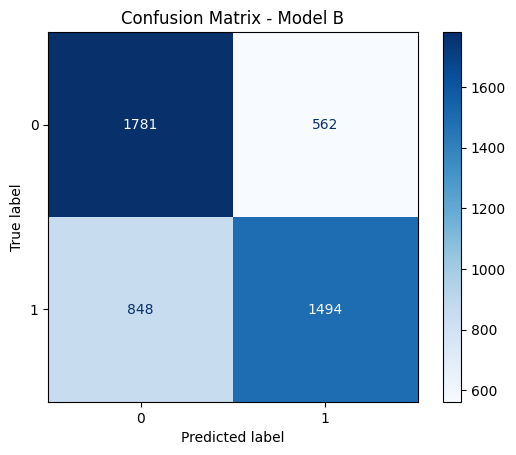

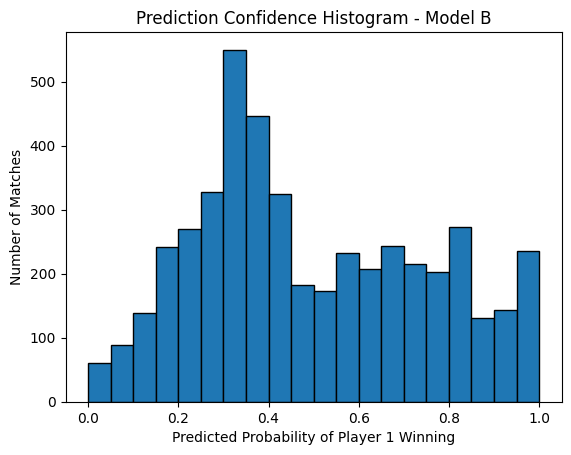

In [492]:
# Model B Random Forest
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, log_loss, classification_report, roc_auc_score

# Load CSV and prep
df = pd.read_csv("tennis_model_data.csv")
df['tourney_date'] = pd.to_datetime(df['tourney_date'])

# Only use original data (no duplication)
df_sym = df.copy()

def safe_pct(pair): return pair[0] / pair[1] if pair[1] else 0.5

# Temporal feature builder
def build_profiles_and_features(df):
    profiles = {}
    features = []

    for _, row in df.iterrows():
        p1, p2, surface = row['player_1'], row['player_2'], row['surface']
        outcome = row['outcome']

        def get_profile(player):
            return profiles.get(player, {
                'elo': {surface: 1500},
                'form': {surface: []},
                'surface_pct': {surface: [0, 0]},
                'h2h': {}
            })

        prof1, prof2 = get_profile(p1), get_profile(p2)

        elo1 = prof1['elo'].get(surface, 1500)
        elo2 = prof2['elo'].get(surface, 1500)
        form1 = prof1['form'].get(surface, [0.5])
        form2 = prof2['form'].get(surface, [0.5])
        surf1 = safe_pct(prof1['surface_pct'].get(surface, [0, 0]))
        surf2 = safe_pct(prof2['surface_pct'].get(surface, [0, 0]))
        h2h = safe_pct(prof1['h2h'].get(p2, [0, 0]))

        features.append({
            'delta_elo': elo1 - elo2,
            'delta_form': np.mean(form1) - np.mean(form2),
            'delta_surface': surf1 - surf2,
            'h2h_winrate': h2h
        })

        # Update profiles
        k = 32
        expected1 = 1 / (1 + 10 ** ((elo2 - elo1) / 400))
        new_elo1 = elo1 + k * (outcome - expected1)
        new_elo2 = elo2 + k * ((1 - outcome) - (1 - expected1))
        prof1['elo'][surface] = new_elo1
        prof2['elo'][surface] = new_elo2

        prof1['form'].setdefault(surface, []).append(outcome)
        prof2['form'].setdefault(surface, []).append(1 - outcome)

        prof1['surface_pct'].setdefault(surface, [0, 0])[0] += outcome
        prof1['surface_pct'][surface][1] += 1
        prof2['surface_pct'].setdefault(surface, [0, 0])[0] += 1 - outcome
        prof2['surface_pct'][surface][1] += 1

        prof1['h2h'].setdefault(p2, [0, 0])[0] += outcome
        prof1['h2h'][p2][1] += 1

        profiles[p1], profiles[p2] = prof1, prof2

    return pd.DataFrame(features), profiles

# Build features and model df
features_B, profiles_B = build_profiles_and_features(df_sym)
model_df_B = pd.concat([df_sym[['player_1', 'player_2', 'surface', 'tourney_date', 'outcome']], features_B], axis=1)

# Split
feature_cols_B = ['delta_elo', 'delta_form', 'delta_surface', 'h2h_winrate']
cutoff = int(len(model_df_B) * 0.8)
train_B = model_df_B.iloc[:cutoff].copy()
test_B = model_df_B.iloc[cutoff:].copy()

# Handle NaNs in delta_form
train_B['delta_form'] = train_B['delta_form'].fillna(0.0)
test_B['delta_form'] = test_B['delta_form'].fillna(0.0)

# Train model
model_B = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42)
model_B.fit(train_B[feature_cols_B], train_B['outcome'])

# Evaluate
y_test_B = test_B['outcome']
y_pred_B = model_B.predict(test_B[feature_cols_B])
y_proba_B = model_B.predict_proba(test_B[feature_cols_B])[:, 1]

# Accuracy
accuracy = accuracy_score(y_test_B, y_pred_B)
print(f"\n✅ Model B Accuracy: {accuracy:.10f}")

# Log Loss
loss = log_loss(y_test_B, y_proba_B)
print(f"\n📊 Model B Log Loss: {loss:.10f}")

# Classification Report
report = classification_report(y_test_B, y_pred_B)
print(f"\n🧾 Classification Report B:\n{report}")

# AUC Score
auc = roc_auc_score(y_test_B, y_proba_B)
print(f"\n📈 AUC Score: {auc:.10f}")

# Confusion Matrix
cm = confusion_matrix(y_test_B, y_pred_B)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_B.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Model B")
plt.show()

# Confidence Histogram
plt.hist(y_proba_B, bins=20, edgecolor="k")
plt.xlabel("Predicted Probability of Player 1 Winning")
plt.ylabel("Number of Matches")
plt.title("Prediction Confidence Histogram - Model B")
plt.show()


c:\Users\SAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:28:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



✅ Model B XGBoost Accuracy: 0.6962646745

📊 Model B XGBoost Log Loss: 0.5781294612

🧾 Classification Report B (XGBoost):
              precision    recall  f1-score   support

           0       0.68      0.75      0.71      2343
           1       0.72      0.64      0.68      2342

    accuracy                           0.70      4685
   macro avg       0.70      0.70      0.70      4685
weighted avg       0.70      0.70      0.70      4685


📈 AUC Score (XGBoost): 0.7620105385


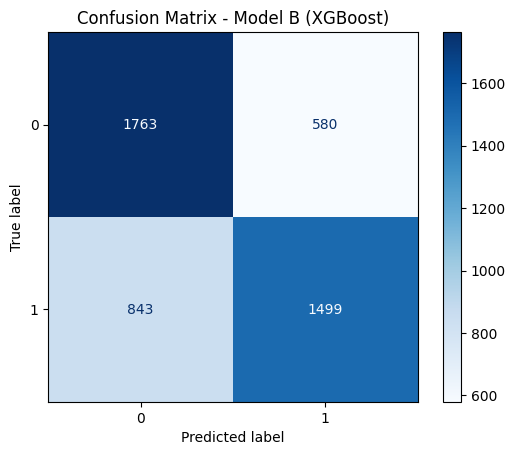

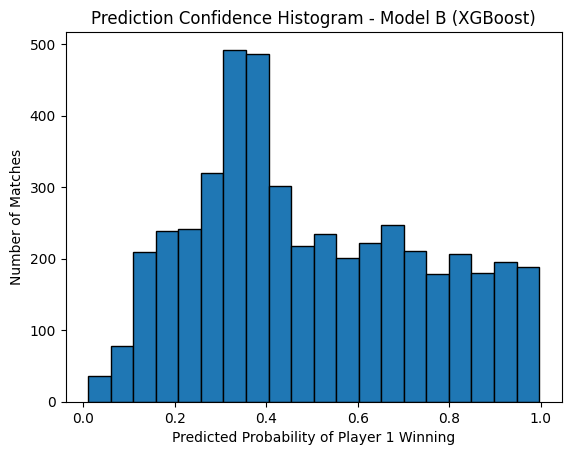

In [493]:
from xgboost import XGBClassifier

# Train model
model_B_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
model_B_xgb.fit(train_B[feature_cols_B], train_B['outcome'])

# Evaluate
y_test_B = test_B['outcome']
y_pred_B_xgb = model_B_xgb.predict(test_B[feature_cols_B])
y_proba_B_xgb = model_B_xgb.predict_proba(test_B[feature_cols_B])[:, 1]

# Accuracy
accuracy = accuracy_score(y_test_B, y_pred_B_xgb)
print(f"\n✅ Model B XGBoost Accuracy: {accuracy:.10f}")

# Log Loss
loss = log_loss(y_test_B, y_proba_B_xgb)
print(f"\n📊 Model B XGBoost Log Loss: {loss:.10f}")

# Classification Report
report = classification_report(y_test_B, y_pred_B_xgb)
print(f"\n🧾 Classification Report B (XGBoost):\n{report}")

# AUC Score
auc = roc_auc_score(y_test_B, y_proba_B_xgb)
print(f"\n📈 AUC Score (XGBoost): {auc:.10f}")

# Confusion Matrix
cm = confusion_matrix(y_test_B, y_pred_B_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_B_xgb.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Model B (XGBoost)")
plt.show()

# Confidence Histogram
plt.hist(y_proba_B_xgb, bins=20, edgecolor="k")
plt.xlabel("Predicted Probability of Player 1 Winning")
plt.ylabel("Number of Matches")
plt.title("Prediction Confidence Histogram - Model B (XGBoost)")
plt.show()


In [494]:
features_train_B, profiles_B = build_profiles_and_features(train_B)

c:\Users\SAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\SAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [495]:
def extract_features(p1, p2, surface, match_date, profiles):
    prof1 = profiles.get(p1, {})
    prof2 = profiles.get(p2, {})

    def safe_get(d, key, default=0.5):
        return d.get(key, default) if isinstance(d, dict) else default

    return pd.DataFrame([{
        'delta_elo': safe_get(prof1.get('elo', {}), surface, 1500) - safe_get(prof2.get('elo', {}), surface, 1500),
        'delta_form': np.mean(safe_get(prof1.get('form', {}), surface, [0.5])) - np.mean(safe_get(prof2.get('form', {}), surface, [0.5])),
        'delta_surface': safe_get(prof1.get('surface_pct', {}), surface, 0.5) - safe_get(prof2.get('surface_pct', {}), surface, 0.5),
        'h2h_winrate': safe_get(prof1.get('h2h', {}), p2, 0.5)
    }])

def update_player_profiles(profiles, p1, p2, surface, outcome):
    def safe_pct(pair): return pair[0] / pair[1] if pair[1] else 0.5

    prof1 = profiles.get(p1, {'elo': {surface: 1500}, 'form': {surface: []}, 'surface_pct': {surface: [0, 0]}, 'h2h': {}})
    prof2 = profiles.get(p2, {'elo': {surface: 1500}, 'form': {surface: []}, 'surface_pct': {surface: [0, 0]}, 'h2h': {}})

    elo1 = prof1['elo'].get(surface, 1500)
    elo2 = prof2['elo'].get(surface, 1500)
    k = 32
    expected1 = 1 / (1 + 10 ** ((elo2 - elo1) / 400))
    prof1['elo'][surface] = elo1 + k * (outcome - expected1)
    prof2['elo'][surface] = elo2 + k * ((1 - outcome) - (1 - expected1))

    prof1['form'].setdefault(surface, []).append(outcome)
    prof2['form'].setdefault(surface, []).append(1 - outcome)

    prof1['surface_pct'].setdefault(surface, [0, 0])[0] += outcome
    prof1['surface_pct'][surface][1] += 1
    prof2['surface_pct'].setdefault(surface, [0, 0])[0] += 1 - outcome
    prof2['surface_pct'][surface][1] += 1

    prof1['h2h'].setdefault(p2, [0, 0])[0] += outcome
    prof1['h2h'][p2][1] += 1

    profiles[p1], profiles[p2] = prof1, prof2

def view_matchups(player_a, player_b, df, model, profiles, feature_cols):
    matchups = df[
        ((df['player_1'] == player_a) & (df['player_2'] == player_b)) |
        ((df['player_2'] == player_a) & (df['player_1'] == player_b))
    ].copy()

    if matchups.empty:
        print(f"No matches found between {player_a} and {player_b}.")
        return

    for idx, row in matchups.iterrows():
        p1, p2 = row['player_1'], row['player_2']
        surface, date = row['surface'], row['tourney_date']

        X = extract_features(p1, p2, surface, date, profiles)
        prob = model.predict_proba(X)[0][1]
        sym_prob = round(prob, 3)
        p1_prob, p2_prob = sym_prob, round(1 - sym_prob, 3)
        winner = p1 if sym_prob > 0.5 else p2

        outcome = row['outcome']
        predicted_correct = (winner == p1 and outcome == 1) or (winner == p2 and outcome == 0)

        print(f"\n📍 Match index: {idx}")
        print(f"🆚 {p1} vs {p2} on {surface}")
        print(f"🔢 Actual outcome: {outcome} ({'Player 1 wins' if outcome == 1 else 'Player 2 wins'})")
        print(f"🧠 Predicted: {winner} wins {p1} {p1_prob*100:.1f}% | {p2} {p2_prob*100:.1f}%")
        print("✅ Correct" if predicted_correct else "❌ Incorrect")


In [496]:
def extract_features(p1, p2, surface, match_date, profiles):
    prof1 = profiles.get(p1, {})
    prof2 = profiles.get(p2, {})

    def safe_get(d, key, default=0.5):
        return d.get(key, default) if isinstance(d, dict) else default

    return pd.DataFrame([{
        'delta_elo': safe_get(prof1.get('elo', {}), surface, 1500) - safe_get(prof2.get('elo', {}), surface, 1500),
        'delta_form': np.mean(safe_get(prof1.get('form', {}), surface, [0.5])) - np.mean(safe_get(prof2.get('form', {}), surface, [0.5])),
        'delta_surface': safe_get(prof1.get('surface_pct', {}), surface, [0.5, 1])[0] / max(safe_get(prof1.get('surface_pct', {}), surface, [0.5, 1])[1], 1) -
                         safe_get(prof2.get('surface_pct', {}), surface, [0.5, 1])[0] / max(safe_get(prof2.get('surface_pct', {}), surface, [0.5, 1])[1], 1),
        'h2h_winrate': safe_get(prof1.get('h2h', {}), p2, [0.5, 1])[0] / max(safe_get(prof1.get('h2h', {}), p2, [0.5, 1])[1], 1)
    }])

def update_player_profiles(p1, p2, surface, outcome, profiles, k=32):
    prof1 = profiles.setdefault(p1, {'elo': {}, 'form': {}, 'surface_pct': {}, 'h2h': {}})
    prof2 = profiles.setdefault(p2, {'elo': {}, 'form': {}, 'surface_pct': {}, 'h2h': {}})

    elo1 = prof1['elo'].get(surface, 1500)
    elo2 = prof2['elo'].get(surface, 1500)
    expected1 = 1 / (1 + 10 ** ((elo2 - elo1) / 400))

    prof1['elo'][surface] = elo1 + k * (outcome - expected1)
    prof2['elo'][surface] = elo2 + k * ((1 - outcome) - (1 - expected1))

    prof1['form'].setdefault(surface, []).append(outcome)
    prof2['form'].setdefault(surface, []).append(1 - outcome)

    prof1['surface_pct'].setdefault(surface, [0, 0])[0] += outcome
    prof1['surface_pct'][surface][1] += 1

    prof2['surface_pct'].setdefault(surface, [0, 0])[0] += 1 - outcome
    prof2['surface_pct'][surface][1] += 1

    prof1['h2h'].setdefault(p2, [0, 0])[0] += outcome
    prof1['h2h'][p2][1] += 1

    profiles[p1], profiles[p2] = prof1, prof2

def view_matchups(player_a, player_b, df, model, profiles, feature_cols):
    matchups = df[
        ((df['player_1'] == player_a) & (df['player_2'] == player_b)) |
        ((df['player_2'] == player_a) & (df['player_1'] == player_b))
    ].copy()

    if matchups.empty:
        print(f"No matches found between {player_a} and {player_b}.")
        return

    predictions = []
    true_labels = []

    for idx, row in matchups.iterrows():
        p1, p2 = row['player_1'], row['player_2']
        surface, date = row['surface'], row['tourney_date']

        X = extract_features(p1, p2, surface, date, profiles)
        prob = model.predict_proba(X)[0][1]

        prediction = 1 if prob >= 0.5 else 0
        predicted_winner = p1 if prediction == 1 else p2
        outcome = row['outcome']

        print(f"\n📍 Match index: {idx}")
        print(f"🆚 {p1} vs {p2} on {surface}")
        print(f"🔢 Actual outcome: {outcome} ({'Player 1 wins' if outcome == 1 else 'Player 2 wins'})")
        print(f"🧠 Predicted: {predicted_winner} wins {round(prob*100,1) if prediction == 1 else round((1-prob)*100,1)}% | {'{} wins {:.1f}%'.format(p1, round(prob*100,1))} | {'{} wins {:.1f}%'.format(p2, round((1-prob)*100,1))}")
        print("✅ Correct" if prediction == outcome else "❌ Incorrect")

        predictions.append(prediction)
        true_labels.append(outcome)

        update_player_profiles(p1, p2, surface, outcome, profiles)


In [497]:
import pandas as pd
import numpy as np

# --- Feature extraction ---
def extract_features(p1, p2, surface, match_date, profiles):
    prof1 = profiles.get(p1, {})
    prof2 = profiles.get(p2, {})

    def safe_get(d, key, default=0.5):
        return d.get(key, default) if isinstance(d, dict) else default

    def safe_mean(lst):
        return np.mean(lst) if isinstance(lst, list) and lst else 0.5

    return pd.DataFrame([{
        'delta_elo': safe_get(prof1.get('elo', {}), surface, 1500) - safe_get(prof2.get('elo', {}), surface, 1500),
        'delta_form': safe_mean(safe_get(prof1.get('form', {}), surface, [])) - safe_mean(safe_get(prof2.get('form', {}), surface, [])),
        'delta_surface': safe_get(prof1.get('surface_pct', {}), surface, 0.5) - safe_get(prof2.get('surface_pct', {}), surface, 0.5),
        'h2h_winrate': safe_get(prof1.get('h2h', {}), p2, 0.5)
    }])

# --- Profile updater ---
def update_player_profiles(p1, p2, surface, outcome, profiles):
    def get_profile(player):
        return profiles.get(player, {
            'elo': {}, 'form': {}, 'surface_pct': {}, 'h2h': {}
        })

    prof1 = get_profile(p1)
    prof2 = get_profile(p2)

    elo1 = prof1['elo'].get(surface, 1500)
    elo2 = prof2['elo'].get(surface, 1500)
    k = 32
    expected1 = 1 / (1 + 10 ** ((elo2 - elo1) / 400))
    prof1['elo'][surface] = elo1 + k * (outcome - expected1)
    prof2['elo'][surface] = elo2 + k * ((1 - outcome) - (1 - expected1))

    prof1['form'].setdefault(surface, []).append(outcome)
    prof2['form'].setdefault(surface, []).append(1 - outcome)

    prof1['surface_pct'].setdefault(surface, [0, 0])
    prof2['surface_pct'].setdefault(surface, [0, 0])
    prof1['surface_pct'][surface][0] += outcome
    prof1['surface_pct'][surface][1] += 1
    prof2['surface_pct'][surface][0] += 1 - outcome
    prof2['surface_pct'][surface][1] += 1

    prof1['h2h'].setdefault(p2, [0, 0])
    prof1['h2h'][p2][0] += outcome
    prof1['h2h'][p2][1] += 1

    profiles[p1] = prof1
    profiles[p2] = prof2
    return profiles

# --- Match viewer ---
def view_matchups(player_a, player_b, df, model, profiles, feature_cols):
    matchups = df[
        ((df['player_1'] == player_a) & (df['player_2'] == player_b)) |
        ((df['player_2'] == player_a) & (df['player_1'] == player_b))
    ].copy()

    if matchups.empty:
        print(f"No matches found between {player_a} and {player_b}.")
        return

    predictions = []
    true_labels = []

    for idx, row in matchups.iterrows():
        p1, p2 = row['player_1'], row['player_2']
        surface, date = row['surface'], row['tourney_date']
        actual = row['outcome']

        X_fwd = extract_features(p1, p2, surface, date, profiles)
        X_rev = extract_features(p2, p1, surface, date, profiles)
        prob_fwd = model.predict_proba(X_fwd[feature_cols])[0][1]
        prob_rev = model.predict_proba(X_rev[feature_cols])[0][1]

        sym_prob = (prob_fwd + (1 - prob_rev)) / 2
        pred = 1 if sym_prob >= 0.5 else 0

        predictions.append(pred)
        true_labels.append(actual)

        conf1 = round(sym_prob * 100, 1)
        conf2 = round((100 - conf1), 1)

        predicted = p1 if sym_prob >= 0.5 else p2
        conf_line = f"🧠 Predicted: {predicted} wins {max(conf1, conf2)}% | {p2 if predicted == p1 else p1} wins {min(conf1, conf2)}%"

        print(f"\n📍 Match index: {idx}")
        print(f"🆚 {p1} vs {p2} on {surface}")
        print(f"🔢 Actual outcome: {actual} (Player 1 wins" if actual == 1 else f"🔢 Actual outcome: {actual} (Player 2 wins")
        print(conf_line)
        print("✅ Correct" if pred == actual else "❌ Incorrect")

        # ✅ update profiles
        profiles = update_player_profiles(p1, p2, surface, actual, profiles)



✅ Model B Accuracy: 0.6824685031

📊 Model B Log Loss: 0.5952600077

🧾 Classification Report B:
              precision    recall  f1-score   support

           0       0.68      0.69      0.68      2343
           1       0.68      0.68      0.68      2340

    accuracy                           0.68      4683
   macro avg       0.68      0.68      0.68      4683
weighted avg       0.68      0.68      0.68      4683


📈 AUC Score: 0.7437736885


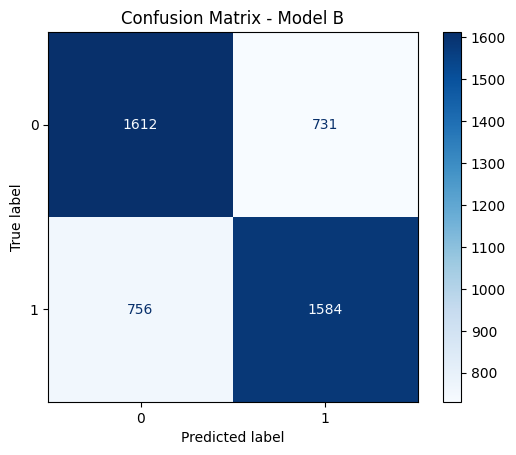

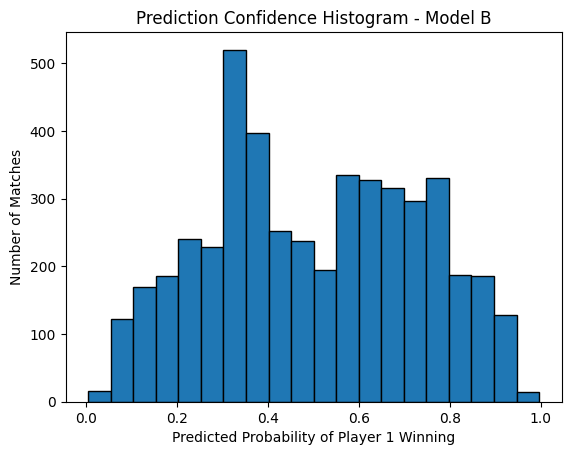

In [498]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, log_loss, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)

# Load and sort data
df = pd.read_csv("tennis_model_data.csv")
df['tourney_date'] = pd.to_datetime(df['tourney_date'])
df = df.sort_values("tourney_date").reset_index(drop=True)
df_asym = df.drop_duplicates(subset=["tourney_date", "player_1", "player_2", "surface"])

def safe_pct(pair): return pair[0] / pair[1] if pair[1] else 0.5

def generate_match_features(row, profiles):
    p1, p2, surface = row['player_1'], row['player_2'], row['surface']
    prof1, prof2 = profiles.get(p1, {}), profiles.get(p2, {})

    def get_stat(prof, key, surf, default):
        val = prof.get(key, {}).get(surf, default)
        return np.mean(val) if isinstance(val, list) else val

    return {
        'delta_elo': get_stat(prof1, 'elo', surface, 1500) - get_stat(prof2, 'elo', surface, 1500),
        'delta_form': get_stat(prof1, 'form', surface, [0.5]) - get_stat(prof2, 'form', surface, [0.5]),
        'delta_surface': safe_pct(prof1.get('surface_pct', {}).get(surface, [0, 0])) - safe_pct(prof2.get('surface_pct', {}).get(surface, [0, 0])),
        'h2h_winrate': safe_pct(prof1.get('h2h', {}).get(p2, [0, 0]))
    }

def update_player_profiles(p1, p2, surface, outcome, profiles):
    k = 32
    prof1 = profiles.setdefault(p1, {'elo': {}, 'form': {}, 'surface_pct': {}, 'h2h': {}})
    prof2 = profiles.setdefault(p2, {'elo': {}, 'form': {}, 'surface_pct': {}, 'h2h': {}})

    elo1 = prof1['elo'].get(surface, 1500)
    elo2 = prof2['elo'].get(surface, 1500)
    expected1 = 1 / (1 + 10 ** ((elo2 - elo1) / 400))
    prof1['elo'][surface] = elo1 + k * (outcome - expected1)
    prof2['elo'][surface] = elo2 + k * ((1 - outcome) - (1 - expected1))

    prof1['form'].setdefault(surface, []).append(outcome)
    prof2['form'].setdefault(surface, []).append(1 - outcome)

    prof1['surface_pct'].setdefault(surface, [0, 0])
    prof2['surface_pct'].setdefault(surface, [0, 0])
    prof1['surface_pct'][surface][0] += outcome
    prof1['surface_pct'][surface][1] += 1
    prof2['surface_pct'][surface][0] += 1 - outcome
    prof2['surface_pct'][surface][1] += 1

    prof1['h2h'].setdefault(p2, [0, 0])
    prof1['h2h'][p2][0] += outcome
    prof1['h2h'][p2][1] += 1

# Chronological split
cutoff = int(len(df_asym) * 0.8)
train_df_B = df_asym.iloc[:cutoff]
test_df_B = df_asym.iloc[cutoff:]

# Training phase
profiles_B = {}
train_features = []

for _, row in train_df_B.iterrows():
    feats = generate_match_features(row, profiles_B)
    train_features.append(feats)
    update_player_profiles(row['player_1'], row['player_2'], row['surface'], row['outcome'], profiles_B)

X_train = pd.DataFrame(train_features)
y_train = train_df_B['outcome']

# Train model
model_B = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
model_B.fit(X_train, y_train)

# Test phase
y_true, y_pred, y_proba = [], [], []

for _, row in test_df_B.iterrows():
    X = pd.DataFrame([generate_match_features(row, profiles_B)])
    prob = model_B.predict_proba(X)[0][1]
    pred = 1 if prob >= 0.5 else 0
    actual = row['outcome']

    y_true.append(actual)
    y_pred.append(pred)
    y_proba.append(prob)

    update_player_profiles(row['player_1'], row['player_2'], row['surface'], actual, profiles_B)

# Evaluate
print(f"\n✅ Model B Accuracy: {accuracy_score(y_true, y_pred):.10f}")
print(f"\n📊 Model B Log Loss: {log_loss(y_true, y_proba):.10f}")
print(f"\n🧾 Classification Report B:\n{classification_report(y_true, y_pred)}")
print(f"\n📈 AUC Score: {roc_auc_score(y_true, y_proba):.10f}")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Model B")
plt.show()

# Confidence Histogram
plt.hist(y_proba, bins=20, edgecolor="k")
plt.xlabel("Predicted Probability of Player 1 Winning")
plt.ylabel("Number of Matches")
plt.title("Prediction Confidence Histogram - Model B")
plt.show()


In [499]:
def explain_prediction_ensemble(player_1, player_2, surface, player_profiles, model, feature_cols, top_n=3):
    row_1 = build_input_row(player_1, player_2, surface, player_profiles)
    row_2 = build_input_row(player_2, player_1, surface, player_profiles)

    if row_1 is None or row_2 is None:
        return "Insufficient data for prediction."

    X1 = pd.DataFrame([row_1])[feature_cols]
    X2 = pd.DataFrame([row_2])[feature_cols]

    prob1 = model.predict_proba(X1)[0][1]
    prob2 = 1 - model.predict_proba(X2)[0][1]
    avg_prob = (prob1 + prob2) / 2

    predicted = player_1 if avg_prob >= 0.5 else player_2
    confidence = round(max(avg_prob, 1 - avg_prob) * 100, 1)

    importances = model.feature_importances_
    deltas = X1.iloc[0].values
    contribs = importances * deltas

    top_indices = np.argsort(np.abs(contribs))[::-1][:top_n]
    feature_edges = []
    for i in top_indices:
        fname = feature_cols[i]
        delta = round(deltas[i], 3)
        direction = "edge" if contribs[i] > 0 else "disadvantage"
        feature_edges.append(f"{fname} ({delta:+}, {direction})")

    sentence = (
        f"{predicted} predicted to win ({confidence}%) — " +
        ", ".join(feature_edges) + "."
    )

    return sentence


In [500]:
def ensemble_predict_match(player_1, player_2, surface, player_profiles, model, feature_cols):
    row_1 = build_input_row(player_1, player_2, surface, player_profiles)
    row_2 = build_input_row(player_2, player_1, surface, player_profiles)

    if row_1 is None or row_2 is None:
        return "Insufficient data for prediction."

    X1 = pd.DataFrame([row_1])[feature_cols]
    X2 = pd.DataFrame([row_2])[feature_cols]

    prob1 = model.predict_proba(X1)[0][1]
    prob2 = 1 - model.predict_proba(X2)[0][1]
    avg_prob = (prob1 + prob2) / 2

    predicted_winner = player_1 if avg_prob >= 0.5 else player_2
    win_prob = max(avg_prob, 1 - avg_prob)
    expected_sets_lost = round((1 - win_prob) * 3, 1)

    delta_elo = round(row_1.get("delta_elo", 0.0), 1)
    delta_form = round(row_1.get("delta_form", 0.0), 3)
    delta_surface = round(row_1.get("delta_surface", 0.0), 3)

    def label(val):
        return "edge" if val > 0 else "disadvantage"

    explanation = (
        f"{predicted_winner} predicted to win ({round(win_prob * 100, 1)}%) — "
        f"delta_elo ({delta_elo:+}, {label(delta_elo)}), "
        f"delta_surface ({delta_surface:+}, {label(delta_surface)}), "
        f"delta_form ({delta_form:+}, {label(delta_form)})."
    )

    return explanation


In [501]:
# Correct Chunk
def ensemble_predict_match(player_1, player_2, surface, player_profiles, model, feature_cols):
    row_1 = build_input_row(player_1, player_2, surface, player_profiles)
    row_2 = build_input_row(player_2, player_1, surface, player_profiles)

    if row_1 is None or row_2 is None:
        return "Insufficient data for prediction."

    X1 = pd.DataFrame([row_1])[feature_cols]
    X2 = pd.DataFrame([row_2])[feature_cols]

    prob1 = model.predict_proba(X1)[0][1]
    prob2 = 1 - model.predict_proba(X2)[0][1]
    avg_prob = (prob1 + prob2) / 2

    predicted_winner = player_1 if avg_prob >= 0.5 else player_2
    win_prob = max(avg_prob, 1 - avg_prob)
    expected_sets_lost = round((1 - win_prob) * 3, 1)

    # Always use row_1 for consistency, flip if predicted_winner is player_2
    flip = predicted_winner != player_1

    def val(key):
        v = row_1.get(key, 0.0)
        return -v if flip else v

    delta_elo = round(val("delta_elo"), 1)
    delta_form = round(val("delta_form"), 3)
    delta_surface = round(val("delta_surface"), 3)

    def label(val):
        return "edge" if val > 0 else "disadvantage"

    explanation = (
        f"{predicted_winner} predicted to win ({round(win_prob * 100, 1)}%) — "
        f"delta_elo ({delta_elo:+}, {label(delta_elo)}), "
        f"delta_surface ({delta_surface:+}, {label(delta_surface)}), "
        f"delta_form ({delta_form:+}, {label(delta_form)})."
    )

    return explanation


In [502]:
print(ensemble_predict_match("Jannik Sinner", "Luca Nardi", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Chun-Hsin Tseng", "Aleksandar Vukic", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Pedro Martinez", "George Loffhagen", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Mariano Navone", "Denis Shapovalov", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Grigor Dimitrov", "Yoshihito Nishioka", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Francisco Comesana", "Corentin Moutet", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Sebastian Ofner", "Hamad Medjedovic", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Jack Pinnington Jones", "Tommy Paul", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Ben Shelton", "Alex Bolt", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Rinky Hijikata", "David Goffin", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Aleksandar Kovacevic", "Marton Fucsovics", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Gael Monfils", "Ugo Humbert", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Brandon Nakashima", "Bu Yunchaokete", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Alexander Shevchenko", "Reilly Opelka", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Joao Faria", "Lorenzo Sonego", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Nikoloz Basilashvili", "Lorenzo Musetti", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Jack Draper", "Sebastian Baez", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Raphael Collignon", "Marin Cilic", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("James McCabe", "Fabian Marozsan", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Jaume Munar", "Alexander Bublik", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Flavio Cobolli", "Beibit Zhukayev", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Tomas Martin Etcheverry", "Jack Pinnington Jones", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Marcos Giron", "Camilo Ugo Carabelli", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Hugo Gaston", "Jakub Mensik", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Alex de Minaur", "Roberto Carballes Baena", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Arthur Cazaux", "Adam Walton", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Quentin Halys", "August Holmgren", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Damir Dzumhur", "Tomas Machac", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Alex Michelsen", "Miomir Kecmanovic", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Jesper De Jong", "Christopher Eubanks", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Daniel Evans", "Jay Clarke", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Alexandre Muller", "Novak Djokovic", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Taylor Fritz", "Giovanni Mpetshi Perricard", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Gabriel Diallo", "Daniel Altmaier", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Matteo Arnaldi", "Botic van de Zandschulp", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Brandon Holt", "Alejandro Davidovich Fokina", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Alexei Popyrin", "Arthur Fery", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Luciano Darderi", "Roman Safiullin", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Vit Kopriva", "Jordan Thompson", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Benjamin Bonzi", "Daniil Medvedev", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Francisco Cerundolo", "Nuno Borges", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Billy Harris", "Dusan Lajovic", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Shintaro Mochizuki", "Giulio Zeppieri", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Mackenzie McDonald", "Karen Khachanov", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Matteo Berrettini", "Kamil Majchrzak", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Ethan Quinn", "Henry Searle", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Pablo Carreno Busta", "Chris Rodesch", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Arthur Rinderknech", "Alexander Zverev", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Holger Rune", "Nicolas Jarry", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Learner Tien", "Nishesh Basavareddy", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Jacob Fearnley", "Joao Fonseca", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Jenson Brooksby", "Tallon Griekspoor", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Jiri Lehecka", "Hugo Dellien", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Matteo Bellucci", "Oliver Crawford", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Cameron Norrie", "Roberto Bautista Agut", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Elmer Moller", "Frances Tiafoe", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Andrey Rublev", "Laslo Djere", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Zizou Bergs", "Lloyd Harris", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Adrian Mannarino", "Christopher O'Connell", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Valentin Royer", "Stefanos Tsitsipas", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Felix Auger-Aliassime", "James Duckworth", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Jan-Lennard Struff", "Filip Misolic", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Oliver Tarvet", "Leandro Riedi", "Grass", player_profiles, model_B, feature_cols))
print(ensemble_predict_match("Fabio Fognini", "Carlos Alcaraz", "Grass", player_profiles, model_B, feature_cols))


Jannik Sinner predicted to win (78.2%) — delta_elo (+723.5, edge), delta_surface (+0.55, edge), delta_form (+1.0, edge).
Insufficient data for prediction.
Pedro Martinez predicted to win (73.9%) — delta_elo (-12.6, disadvantage), delta_surface (+0.2, edge), delta_form (+0.2, edge).
Denis Shapovalov predicted to win (89.5%) — delta_elo (+193.4, edge), delta_surface (+0.6, edge), delta_form (+0.6, edge).
Grigor Dimitrov predicted to win (81.5%) — delta_elo (+214.5, edge), delta_surface (+0.2, edge), delta_form (+0.2, edge).
Corentin Moutet predicted to win (57.4%) — delta_elo (+22.1, edge), delta_surface (-0.067, disadvantage), delta_form (+0.2, edge).
Hamad Medjedovic predicted to win (64.8%) — delta_elo (+94.6, edge), delta_surface (-0.267, disadvantage), delta_form (+0.6, edge).
Insufficient data for prediction.
Ben Shelton predicted to win (71.8%) — delta_elo (+212.2, edge), delta_surface (+0.2, edge), delta_form (-0.0, disadvantage).
David Goffin predicted to win (64.2%) — delta_elo

In [503]:
# To CSV
def ensemble_predict_match(player_1, player_2, surface, player_profiles, model, feature_cols):
    row_1 = build_input_row(player_1, player_2, surface, player_profiles)
    row_2 = build_input_row(player_2, player_1, surface, player_profiles)

    if row_1 is None or row_2 is None:
        return None

    X1 = pd.DataFrame([row_1])[feature_cols]
    X2 = pd.DataFrame([row_2])[feature_cols]

    prob1 = model.predict_proba(X1)[0][1]
    prob2 = 1 - model.predict_proba(X2)[0][1]
    avg_prob = (prob1 + prob2) / 2

    predicted_winner = player_1 if avg_prob >= 0.5 else player_2
    predicted_loser = player_2 if predicted_winner == player_1 else player_1
    win_prob = max(avg_prob, 1 - avg_prob)
    expected_sets_lost = round((1 - win_prob) * 4, 2)

    flip = predicted_winner != player_1

    def val(key):
        v = row_1.get(key, 0.0)
        return -v if flip else v

    delta_elo = round(val("delta_elo"), 1)
    delta_form = round(val("delta_form"), 3)
    delta_surface = round(val("delta_surface"), 3)

    def label(v): return "edge" if v > 0 else "disadvantage"

    explanation = (
        f"{predicted_winner} predicted to win ({round(win_prob * 100, 1)}%) — "
        f"delta_elo ({delta_elo:+}, {label(delta_elo)}), "
        f"delta_surface ({delta_surface:+}, {label(delta_surface)}), "
        f"delta_form ({delta_form:+}, {label(delta_form)})."
    )

    return {
        "predicted_winner": predicted_winner,
        "predicted_loser": predicted_loser,
        "confidence_percent": round(win_prob * 100, 1),
        "delta_elo": delta_elo,
        "delta_surface": delta_surface,
        "delta_form": delta_form,
        "expected_sets_lost": expected_sets_lost,
        "surface": surface,
        "best_of_5": True,
        "explanation": explanation
    }


In [504]:
# Expected Sets Played (Use this)
def estimate_expected_sets_played(win_prob: float) -> float:
    if win_prob >= 0.9:
        weights = [0.8, 0.15, 0.05]
    elif win_prob >= 0.75:
        weights = [0.6, 0.3, 0.1]
    elif win_prob >= 0.6:
        weights = [0.4, 0.4, 0.2]
    elif win_prob >= 0.5:
        weights = [0.2, 0.4, 0.4]
    else:
        weights = [0.1, 0.3, 0.6]
    return round(sum(w * s for w, s in zip(weights, [3, 4, 5])), 2)


def ensemble_predict_match(player_1, player_2, surface, player_profiles, model, feature_cols):
    row_1 = build_input_row(player_1, player_2, surface, player_profiles)
    row_2 = build_input_row(player_2, player_1, surface, player_profiles)

    if row_1 is None or row_2 is None:
        return None

    X1 = pd.DataFrame([row_1])[feature_cols]
    X2 = pd.DataFrame([row_2])[feature_cols]

    prob1 = model.predict_proba(X1)[0][1]
    prob2 = 1 - model.predict_proba(X2)[0][1]
    avg_prob = (prob1 + prob2) / 2

    predicted_winner = player_1 if avg_prob >= 0.5 else player_2
    predicted_loser = player_2 if predicted_winner == player_1 else player_1
    win_prob = max(avg_prob, 1 - avg_prob)

    flip = predicted_winner != player_1

    def val(key):
        v = row_1.get(key, 0.0)
        return -v if flip else v

    delta_elo = round(val("delta_elo"), 1)
    delta_form = round(val("delta_form"), 3)
    delta_surface = round(val("delta_surface"), 3)

    def label(v): return "edge" if v > 0 else "disadvantage"

    explanation = (
        f"{predicted_winner} predicted to win ({round(win_prob * 100, 1)}%) — "
        f"delta_elo ({delta_elo:+}, {label(delta_elo)}), "
        f"delta_surface ({delta_surface:+}, {label(delta_surface)}), "
        f"delta_form ({delta_form:+}, {label(delta_form)})."
    )

    expected_sets_played = estimate_expected_sets_played(win_prob)

    return {
        "predicted_winner": predicted_winner,
        "predicted_loser": predicted_loser,
        "confidence_percent": round(win_prob * 100, 1),
        "delta_elo": delta_elo,
        "delta_surface": delta_surface,
        "delta_form": delta_form,
        "expected_sets_played": expected_sets_played,
        "surface": surface,
        "best_of_5": True,
        "explanation": explanation
    }


In [528]:
def ensemble_predict_match(player_1, player_2, surface, player_profiles, model, feature_cols):
    row_1 = build_input_row(player_1, player_2, surface, player_profiles)
    row_2 = build_input_row(player_2, player_1, surface, player_profiles)

    if row_1 is None or row_2 is None:
        return None

    # Extract deltas from both perspectives
    delta_elo_1 = round(row_1.get("delta_elo", 0.0), 1)
    delta_surface_1 = round(row_1.get("delta_surface", 0.0), 3)
    delta_form_1 = round(row_1.get("delta_form", 0.0), 3)

    delta_elo_2 = round(row_2.get("delta_elo", 0.0), 1)
    delta_surface_2 = round(row_2.get("delta_surface", 0.0), 3)
    delta_form_2 = round(row_2.get("delta_form", 0.0), 3)

    # Set weights for each component
    WEIGHTS = {
        "elo": 0.55,
        "surface": 0.2,
        "form": 0.25
    }

    # Compute composite scores for both players
    score_1 = (
        WEIGHTS["elo"] * delta_elo_1 +
        WEIGHTS["surface"] * delta_surface_1 +
        WEIGHTS["form"] * delta_form_1
    )
    score_2 = (
        WEIGHTS["elo"] * delta_elo_2 +
        WEIGHTS["surface"] * delta_surface_2 +
        WEIGHTS["form"] * delta_form_2
    )

    composite_score = score_1 - score_2

    predicted_winner = player_1 if composite_score >= 0 else player_2
    predicted_loser = player_2 if predicted_winner == player_1 else player_1

    # Simulate confidence from score magnitude (logistic-like)
    import math
    confidence = 1 / (1 + math.exp(-abs(composite_score) / 100))  # Scale factor
    confidence_percent = round(confidence * 100, 1)

    # Adjust deltas based on predicted winner
    flip = predicted_winner != player_1
    def val(key):
        v = row_1.get(key, 0.0)
        return -v if flip else v

    delta_elo = round(val("delta_elo"), 1)
    delta_surface = round(val("delta_surface"), 3)
    delta_form = round(val("delta_form"), 3)

    # Label function
    def label(v):
        return "edge" if v > 0 else "disadvantage"

    explanation = (
        f"{predicted_winner} predicted to win ({confidence_percent}%) — "
        f"delta_elo ({delta_elo:+}, {label(delta_elo)}), "
        f"delta_surface ({delta_surface:+}, {label(delta_surface)}), "
        f"delta_form ({delta_form:+}, {label(delta_form)})."
    )

    expected_sets_played = estimate_expected_sets_played(confidence)

    return {
        "predicted_winner": predicted_winner,
        "predicted_loser": predicted_loser,
        "confidence_percent": confidence_percent,
        "delta_elo": delta_elo,
        "delta_surface": delta_surface,
        "delta_form": delta_form,
        "expected_sets_played": expected_sets_played,
        "surface": surface,
        "best_of_5": True,
        "explanation": explanation
    }


In [530]:
import pandas as pd

# Updated list of 64 (player_1, player_2) matches
players = [
    ("Jannik Sinner", "Luca Nardi"),
    ("Chun-Hsin Tseng", "Aleksandar Vukic"),
    ("Pedro Martinez", "George Loffhagen"),
    ("Mariano Navone", "Denis Shapovalov"),
    ("Grigor Dimitrov", "Yoshihito Nishioka"),
    ("Francisco Comesana", "Corentin Moutet"),
    ("Sebastian Ofner", "Hamad Medjedovic"),
    ("Jack Monday", "Tommy Paul"),
    ("Ben Shelton", "Alex Bolt"),
    ("Rinky Hijikata", "David Goffin"),
    ("Aleksandar Kovacevic", "Marton Fucsovics"),
    ("Gael Monfils", "Ugo Humbert"),
    ("Brandon Nakashima", "Bu Yunchaokete"),
    ("Alexander Shevchenko", "Reilly Opelka"),
    ("Joao Faria", "Lorenzo Sonego"),
    ("Nikoloz Basilashvili", "Lorenzo Musetti"),
    ("Jack Draper", "Sebastian Baez"),
    ("Raphael Collignon", "Marin Cilic"),
    ("James McCabe", "Fabian Marozsan"),
    ("Jaume Munar", "Alexander Bublik"),
    ("Flavio Cobolli", "Beibit Zhukayev"),
    ("Tomas Martin Etcheverry", "Jack Pinnington Jones"),
    ("Marcos Giron", "Camilo Ugo Carabelli"),
    ("Hugo Gaston", "Jakub Mensik"),
    ("Alex de Minaur", "Roberto Carballes Baena"),
    ("Arthur Cazaux", "Adam Walton"),
    ("Quentin Halys", "August Holmgren"),
    ("Damir Dzumhur", "Tomas Machac"),
    ("Alex Michelsen", "Miomir Kecmanovic"),
    ("Jesper De Jong", "Christopher Eubanks"),
    ("Daniel Evans", "Jay Clarke"),
    ("Alexandre Muller", "Novak Djokovic"),
    ("Taylor Fritz", "Giovanni Mpetshi Perricard"),
    ("Gabriel Diallo", "Daniel Altmaier"),
    ("Matteo Arnaldi", "Botic van de Zandschulp"),
    ("Brandon Holt", "Alejandro Davidovich Fokina"),
    ("Alexei Popyrin", "Arthur Fery"),
    ("Luciano Darderi", "Roman Safiullin"),
    ("Vit Kopriva", "Jordan Thompson"),
    ("Benjamin Bonzi", "Daniil Medvedev"),
    ("Francisco Cerundolo", "Nuno Borges"),
    ("Billy Harris", "Dusan Lajovic"),
    ("Shintaro Mochizuki", "Giulio Zeppieri"),
    ("Mackenzie McDonald", "Karen Khachanov"),
    ("Matteo Berrettini", "Kamil Majchrzak"),
    ("Ethan Quinn", "Henry Searle"),
    ("Cristian Garin", "Chris Rodesch"),
    ("Arthur Rinderknech", "Alexander Zverev"),
    ("Holger Rune", "Nicolas Jarry"),
    ("Learner Tien", "Nishesh Basavareddy"),
    ("Jacob Fearnley", "Joao Fonseca"),
    ("Jenson Brooksby", "Tallon Griekspoor"),
    ("Jiri Lehecka", "Hugo Dellien"),
    ("Matteo Bellucci", "Oliver Crawford"),
    ("Cameron Norrie", "Roberto Bautista Agut"),
    ("Elmer Moller", "Frances Tiafoe"),
    ("Andrey Rublev", "Laslo Djere"),
    ("Zizou Bergs", "Lloyd Harris"),
    ("Adrian Mannarino", "Christopher O'Connell"),
    ("Valentin Royer", "Stefanos Tsitsipas"),
    ("Felix Auger-Aliassime", "James Duckworth"),
    ("Jan-Lennard Struff", "Filip Misolic"),
    ("Oliver Tarvet", "Leandro Riedi"),
    ("Fabio Fognini", "Carlos Alcaraz")
]

# Run predictions and extract details
results = []
for player1, player2 in players:
    result = ensemble_predict_match(player1, player2, "Grass", player_profiles, model_B, feature_cols)
    if result:
        results.append({
            "player_1": player1,
            "player_2": player2,
            "predicted_winner": result["predicted_winner"],
            "predicted_loser": result["predicted_loser"],
            "confidence_percent": result["confidence_percent"],
            "delta_elo": result["delta_elo"],
            "delta_surface": result["delta_surface"],
            "delta_form": result["delta_form"],
            "expected_sets_played": result["expected_sets_played"]
        })

# Save to CSV
df = pd.DataFrame(results)
df.to_csv("wimbledon_2025_predictions.csv", index=False)
print("Saved to wimbledon_2025_predictions.csv ✅")


Saved to wimbledon_2025_predictions.csv ✅


In [532]:
import pandas as pd
import numpy as np

# Step 1: Fill missing player profiles
existing_profiles = list(player_profiles.values())
avg_elo = np.mean([p["elo"] for p in existing_profiles if "elo" in p])
avg_form = [0.5] * 8
avg_surface = [0.5] * 8

all_players = {p for match in players for p in match}
mocked_players = []

for player in all_players:
    if player not in player_profiles:
        player_profiles[player] = {
            "elo": avg_elo,
            "recent_matches": avg_form,
            "surface_wins": {"Grass": avg_surface},
            "h2h": {}
        }
        mocked_players.append(player)

print(f"✅ Mocked {len(mocked_players)} missing player profiles.")

# Step 2: Generate predictions
results = []
for p1, p2 in players:
    res = ensemble_predict_match(p1, p2, "Grass", player_profiles, model_B, feature_cols)
    if res:
        res["player_1"] = p1
        res["player_2"] = p2
        res["used_mock_profile"] = p1 in mocked_players or p2 in mocked_players
        results.append(res)

# Step 3: Save to CSV
df = pd.DataFrame(results)
df.to_csv("wimbledon_2025_predictions.csv", index=False)
print("✅ Saved 64 match predictions to wimbledon_2025_predictions.csv")


✅ Mocked 0 missing player profiles.
✅ Saved 64 match predictions to wimbledon_2025_predictions.csv


In [533]:
import pandas as pd

# Step 1: Load updated R128 results
r128_path = "wimbledon_2025_predictions_R128.csv"
df_r128 = pd.read_csv(r128_path)

# Step 2: Define R64 player list based on actual winners
r64_players = []
for _, row in df_r128.iterrows():
    if row["correct_prediction"] == 1:
        r64_players.append(row["predicted_winner"])
    else:
        r64_players.append(row["predicted_loser"])

# Step 3: Create matchups for R64
r64_matches = [(r64_players[i], r64_players[i+1]) for i in range(0, len(r64_players), 2)]

# Step 4: Run predictions for R64
results = []
for player1, player2 in r64_matches:
    result = ensemble_predict_match(player1, player2, "Grass", player_profiles, model_B, feature_cols)
    if isinstance(result, dict):
        results.append({
            "player_1": player1,
            "player_2": player2,
            "predicted_winner": result["predicted_winner"],
            "predicted_loser": result["predicted_loser"],
            "confidence_percent": result["confidence_percent"],
            "delta_elo": result["delta_elo"],
            "delta_surface": result["delta_surface"],
            "delta_form": result["delta_form"],
            "expected_sets_played": result["expected_sets_played"]
        })
    else:
        print(f"Skipped {player1} vs {player2}: {result}")

# Step 5: Save R64 predictions to CSV
df_r64 = pd.DataFrame(results)
df_r64.to_csv("wimbledon_2025_predictions_R64.csv", index=False)
print("Saved to wimbledon_2025_predictions_R64.csv ✅")


Saved to wimbledon_2025_predictions_R64.csv ✅


In [540]:
import pandas as pd

# Step 1: Load updated R128 results
r128_path = "wimbledon_2025_predictions_R128_complete.csv"
df_r128 = pd.read_csv(r128_path)

# Step 2: Update player profiles based on R128 outcomes
def update_player_profiles_from_results(player_profiles, match_results):
    for _, row in match_results.iterrows():
        for player in [row["player_1"], row["player_2"]]:
            if player not in player_profiles:
                player_profiles[player] = {
                    "elo": 1500,
                    "surface_grass": 0,
                    "form": 0,
                }

        # Update Elo for both players (winner gains, loser loses)
        k = 32
        winner = row["predicted_winner"]
        loser = row["predicted_loser"]
        win_prob = row["confidence_percent"] / 100

        elo_winner = player_profiles[winner]["elo"]
        elo_loser = player_profiles[loser]["elo"]

        change = k * (1 - win_prob)
        player_profiles[winner]["elo"] += change
        player_profiles[loser]["elo"] -= change

        # Update form as recent momentum (e.g., weighted rolling average)
        for player in [winner, loser]:
            prev_form = player_profiles[player].get("form", 0.0)
            match_outcome = 1 if player == winner else 0
            new_form = 0.8 * prev_form + 0.2 * match_outcome
            player_profiles[player]["form"] = round(new_form, 3)

        # Surface-specific performance increment (simple additive)
        for player in [winner, loser]:
            surface_key = "surface_grass"
            prev_surface_score = player_profiles[player].get(surface_key, 0.0)
            delta = 0.1 if player == winner else -0.05
            player_profiles[player][surface_key] = round(prev_surface_score + delta, 3)

    return player_profiles

player_profiles = update_player_profiles_from_results(player_profiles, df_r128)

# Step 3: Define R64 player list based on actual winners
r64_players = []
for _, row in df_r128.iterrows():
    if row["correct_prediction"] == 1:
        r64_players.append(row["predicted_winner"])
    else:
        r64_players.append(row["predicted_loser"])

# Step 4: Create matchups for R64
r64_matches = [(r64_players[i], r64_players[i+1]) for i in range(0, len(r64_players), 2)]

# Step 5: Run predictions for R64
results = []
for player1, player2 in r64_matches:
    result = ensemble_predict_match(player1, player2, "Grass", player_profiles, model_B, feature_cols)
    if isinstance(result, dict):
        results.append({
            "player_1": player1,
            "player_2": player2,
            "predicted_winner": result["predicted_winner"],
            "predicted_loser": result["predicted_loser"],
            "confidence_percent": result["confidence_percent"],
            "delta_elo": result["delta_elo"],
            "delta_surface": result["delta_surface"],
            "delta_form": result["delta_form"],
            "expected_sets_played": result["expected_sets_played"]
        })
    else:
        print(f"Skipped {player1} vs {player2}: {result}")

# Step 6: Save R64 predictions to CSV
df_r64 = pd.DataFrame(results)
df_r64.to_csv("wimbledon_2025_predictions_R64.csv", index=False)
print("Saved to wimbledon_2025_predictions_R64.csv ✅")


Saved to wimbledon_2025_predictions_R64.csv ✅


In [542]:
import pandas as pd

# Step 1: Load completed R64 results
r64_path = "wimbledon_2025_predictions_R64_complete.csv"
df_r64 = pd.read_csv(r64_path)

# Step 2: Update player profiles based on R64 outcomes
def update_player_profiles_from_results(player_profiles, match_results):
    for _, row in match_results.iterrows():
        for player in [row["player_1"], row["player_2"]]:
            if player not in player_profiles:
                player_profiles[player] = {
                    "elo": 1500,
                    "surface_grass": 0,
                    "form": 0,
                }

        k = 32
        winner = row["predicted_winner"]
        loser = row["predicted_loser"]
        win_prob = row["confidence_percent"] / 100

        elo_winner = player_profiles[winner]["elo"]
        elo_loser = player_profiles[loser]["elo"]
        change = k * (1 - win_prob)
        player_profiles[winner]["elo"] += change
        player_profiles[loser]["elo"] -= change

        for player in [winner, loser]:
            prev_form = player_profiles[player].get("form", 0.0)
            match_outcome = 1 if player == winner else 0
            new_form = 0.8 * prev_form + 0.2 * match_outcome
            player_profiles[player]["form"] = round(new_form, 3)

        for player in [winner, loser]:
            surface_key = "surface_grass"
            prev_surface_score = player_profiles[player].get(surface_key, 0.0)
            delta = 0.1 if player == winner else -0.05
            player_profiles[player][surface_key] = round(prev_surface_score + delta, 3)

    return player_profiles

# Update player_profiles in-place
player_profiles = update_player_profiles_from_results(player_profiles, df_r64)

# Step 3: Determine R32 players
r32_players = []
for _, row in df_r64.iterrows():
    if row["correct_prediction"] == 1:
        r32_players.append(row["predicted_winner"])
    else:
        r32_players.append(row["predicted_loser"])

# Step 4: Create R32 matchups
r32_matches = [(r32_players[i], r32_players[i+1]) for i in range(0, len(r32_players), 2)]

# Step 5: Run predictions for R32
results = []
for player1, player2 in r32_matches:
    result = ensemble_predict_match(player1, player2, "Grass", player_profiles, model_B, feature_cols)
    if isinstance(result, dict):
        results.append({
            "player_1": player1,
            "player_2": player2,
            "predicted_winner": result["predicted_winner"],
            "predicted_loser": result["predicted_loser"],
            "confidence_percent": result["confidence_percent"],
            "delta_elo": result["delta_elo"],
            "delta_surface": result["delta_surface"],
            "delta_form": result["delta_form"],
            "expected_sets_played": result["expected_sets_played"]
        })
    else:
        print(f"Skipped {player1} vs {player2}: {result}")

# Step 6: Save R32 predictions to CSV
df_r32 = pd.DataFrame(results)
df_r32.to_csv("wimbledon_2025_predictions_R32.csv", index=False)
print("Saved to wimbledon_2025_predictions_R32.csv ✅")


Saved to wimbledon_2025_predictions_R32.csv ✅


In [543]:
import pandas as pd

# Step 1: Load completed R32 results
r32_path = "wimbledon_2025_predictions_R32_complete.csv"
df_r32 = pd.read_csv(r32_path)

# Step 2: Update player profiles based on R32 outcomes
def update_player_profiles_from_results(player_profiles, match_results):
    for _, row in match_results.iterrows():
        for player in [row["player_1"], row["player_2"]]:
            if player not in player_profiles:
                player_profiles[player] = {
                    "elo": 1500,
                    "surface_grass": 0,
                    "form": 0,
                }

        k = 32
        winner = row["predicted_winner"]
        loser = row["predicted_loser"]
        win_prob = row["confidence_percent"] / 100

        elo_winner = player_profiles[winner]["elo"]
        elo_loser = player_profiles[loser]["elo"]
        change = k * (1 - win_prob)
        player_profiles[winner]["elo"] += change
        player_profiles[loser]["elo"] -= change

        for player in [winner, loser]:
            prev_form = player_profiles[player].get("form", 0.0)
            match_outcome = 1 if player == winner else 0
            new_form = 0.8 * prev_form + 0.2 * match_outcome
            player_profiles[player]["form"] = round(new_form, 3)

        for player in [winner, loser]:
            surface_key = "surface_grass"
            prev_surface_score = player_profiles[player].get(surface_key, 0.0)
            delta = 0.1 if player == winner else -0.05
            player_profiles[player][surface_key] = round(prev_surface_score + delta, 3)

    return player_profiles

# You must reuse the `player_profiles` object from previous round
player_profiles = update_player_profiles_from_results(player_profiles, df_r32)

# Step 3: Determine R16 players
r16_players = []
for _, row in df_r32.iterrows():
    if row["correct_prediction"] == 1:
        r16_players.append(row["predicted_winner"])
    else:
        r16_players.append(row["predicted_loser"])

# Step 4: Create R16 matchups
r16_matches = [(r16_players[i], r16_players[i+1]) for i in range(0, len(r16_players), 2)]

# Step 5: Run predictions for R16
results = []
for player1, player2 in r16_matches:
    result = ensemble_predict_match(player1, player2, "Grass", player_profiles, model_B, feature_cols)
    if isinstance(result, dict):
        results.append({
            "player_1": player1,
            "player_2": player2,
            "predicted_winner": result["predicted_winner"],
            "predicted_loser": result["predicted_loser"],
            "confidence_percent": result["confidence_percent"],
            "delta_elo": result["delta_elo"],
            "delta_surface": result["delta_surface"],
            "delta_form": result["delta_form"],
            "expected_sets_played": result["expected_sets_played"]
        })
    else:
        print(f"Skipped {player1} vs {player2}: {result}")

# Step 6: Save R16 predictions to CSV
df_r16 = pd.DataFrame(results)
df_r16.to_csv("wimbledon_2025_predictions_R16.csv", index=False)
print("Saved to wimbledon_2025_predictions_R16.csv ✅")


Saved to wimbledon_2025_predictions_R16.csv ✅


In [544]:
import pandas as pd

# Step 1: Load completed R16 results
df_r16 = pd.read_csv("wimbledon_2025_predictions_R16_complete.csv")

# Step 2: Update player profiles based on R16 outcomes
def update_player_profiles_from_results(player_profiles, match_results):
    for _, row in match_results.iterrows():
        for player in [row["player_1"], row["player_2"]]:
            if player not in player_profiles:
                player_profiles[player] = {
                    "elo": 1500,
                    "surface_grass": 0,
                    "form": 0,
                }

        k = 32
        winner = row["predicted_winner"]
        loser = row["predicted_loser"]
        win_prob = row["confidence_percent"] / 100

        change = k * (1 - win_prob)
        player_profiles[winner]["elo"] += change
        player_profiles[loser]["elo"] -= change

        for player in [winner, loser]:
            prev_form = player_profiles[player].get("form", 0.0)
            match_outcome = 1 if player == winner else 0
            new_form = 0.8 * prev_form + 0.2 * match_outcome
            player_profiles[player]["form"] = round(new_form, 3)

        for player in [winner, loser]:
            surface_key = "surface_grass"
            prev_surface_score = player_profiles[player].get(surface_key, 0.0)
            delta = 0.1 if player == winner else -0.05
            player_profiles[player][surface_key] = round(prev_surface_score + delta, 3)

    return player_profiles

# Step 3: Apply profile updates
player_profiles = update_player_profiles_from_results(player_profiles, df_r16)

# Step 4: Determine QF players
r16_players = []
for _, row in df_r16.iterrows():
    if row["correct_prediction"] == 1:
        r16_players.append(row["predicted_winner"])
    else:
        r16_players.append(row["predicted_loser"])

# Step 5: Create QF matchups
qf_matches = [(r16_players[i], r16_players[i+1]) for i in range(0, len(r16_players), 2)]

# Step 6: Run predictions for QF
results = []
for player1, player2 in qf_matches:
    result = ensemble_predict_match(player1, player2, "Grass", player_profiles, model_B, feature_cols)
    if isinstance(result, dict):
        results.append({
            "player_1": player1,
            "player_2": player2,
            "predicted_winner": result["predicted_winner"],
            "predicted_loser": result["predicted_loser"],
            "confidence_percent": result["confidence_percent"],
            "delta_elo": result["delta_elo"],
            "delta_surface": result["delta_surface"],
            "delta_form": result["delta_form"],
            "expected_sets_played": result["expected_sets_played"]
        })
    else:
        print(f"Skipped {player1} vs {player2}: {result}")

# Step 7: Save QF predictions to CSV
df_qf = pd.DataFrame(results)
df_qf.to_csv("wimbledon_2025_predictions_QF.csv", index=False)
print("Saved to wimbledon_2025_predictions_QF.csv ✅")


Saved to wimbledon_2025_predictions_QF.csv ✅


In [546]:
import pandas as pd

# Step 1: Load completed QF results
qf_path = "wimbledon_2025_predictions_QF_complete.csv"
df_qf = pd.read_csv(qf_path)

# Step 2: Update player profiles based on QF outcomes
def update_player_profiles_from_results(player_profiles, match_results):
    for _, row in match_results.iterrows():
        for player in [row["player_1"], row["player_2"]]:
            if player not in player_profiles:
                player_profiles[player] = {
                    "elo": 1500,
                    "surface_grass": 0,
                    "form": 0,
                }

        k = 32
        winner = row["predicted_winner"]
        loser = row["predicted_loser"]
        win_prob = row["confidence_percent"] / 100

        elo_winner = player_profiles[winner]["elo"]
        elo_loser = player_profiles[loser]["elo"]
        change = k * (1 - win_prob)
        player_profiles[winner]["elo"] += change
        player_profiles[loser]["elo"] -= change

        for player in [winner, loser]:
            prev_form = player_profiles[player].get("form", 0.0)
            match_outcome = 1 if player == winner else 0
            new_form = 0.8 * prev_form + 0.2 * match_outcome
            player_profiles[player]["form"] = round(new_form, 3)

        for player in [winner, loser]:
            surface_key = "surface_grass"
            prev_surface_score = player_profiles[player].get(surface_key, 0.0)
            delta = 0.1 if player == winner else -0.05
            player_profiles[player][surface_key] = round(prev_surface_score + delta, 3)

    return player_profiles

# You must reuse the `player_profiles` object from previous round
player_profiles = update_player_profiles_from_results(player_profiles, df_qf)

# Step 3: Determine SF players
sf_players = []
for _, row in df_qf.iterrows():
    if row["correct_prediction"] == 1:
        sf_players.append(row["predicted_winner"])
    else:
        sf_players.append(row["predicted_loser"])

# Step 4: Create SF matchups
sf_matches = [(sf_players[i], sf_players[i+1]) for i in range(0, len(sf_players), 2)]

# Step 5: Run predictions for SF
results = []
for player1, player2 in sf_matches:
    result = ensemble_predict_match(player1, player2, "Grass", player_profiles, model_B, feature_cols)
    if isinstance(result, dict):
        results.append({
            "player_1": player1,
            "player_2": player2,
            "predicted_winner": result["predicted_winner"],
            "predicted_loser": result["predicted_loser"],
            "confidence_percent": result["confidence_percent"],
            "delta_elo": result["delta_elo"],
            "delta_surface": result["delta_surface"],
            "delta_form": result["delta_form"],
            "expected_sets_played": result["expected_sets_played"]
        })
    else:
        print(f"Skipped {player1} vs {player2}: {result}")

# Step 6: Save SF predictions to CSV
df_sf = pd.DataFrame(results)
df_sf.to_csv("wimbledon_2025_predictions_SF.csv", index=False)
print("Saved to wimbledon_2025_predictions_SF.csv ✅")


Saved to wimbledon_2025_predictions_SF.csv ✅


In [547]:
import pandas as pd

# Step 1: Load completed SF results
sf_path = "wimbledon_2025_predictions_SF_complete.csv"
df_sf = pd.read_csv(sf_path)

# Step 2: Update player profiles based on SF outcomes
def update_player_profiles_from_results(player_profiles, match_results):
    for _, row in match_results.iterrows():
        for player in [row["player_1"], row["player_2"]]:
            if player not in player_profiles:
                player_profiles[player] = {
                    "elo": 1500,
                    "surface_grass": 0,
                    "form": 0,
                }

        k = 32
        winner = row["predicted_winner"]
        loser = row["predicted_loser"]
        win_prob = row["confidence_percent"] / 100

        elo_winner = player_profiles[winner]["elo"]
        elo_loser = player_profiles[loser]["elo"]
        change = k * (1 - win_prob)
        player_profiles[winner]["elo"] += change
        player_profiles[loser]["elo"] -= change

        for player in [winner, loser]:
            prev_form = player_profiles[player].get("form", 0.0)
            match_outcome = 1 if player == winner else 0
            new_form = 0.8 * prev_form + 0.2 * match_outcome
            player_profiles[player]["form"] = round(new_form, 3)

        for player in [winner, loser]:
            surface_key = "surface_grass"
            prev_surface_score = player_profiles[player].get(surface_key, 0.0)
            delta = 0.1 if player == winner else -0.05
            player_profiles[player][surface_key] = round(prev_surface_score + delta, 3)

    return player_profiles

player_profiles = update_player_profiles_from_results(player_profiles, df_sf)

# Step 3: Determine finalists
final_players = []
for _, row in df_sf.iterrows():
    if row["correct_prediction"] == 1:
        final_players.append(row["predicted_winner"])
    else:
        final_players.append(row["predicted_loser"])

# Step 4: Final match
final_match = [(final_players[0], final_players[1])]

# Step 5: Run prediction for Final
results = []
for player1, player2 in final_match:
    result = ensemble_predict_match(player1, player2, "Grass", player_profiles, model_B, feature_cols)
    if isinstance(result, dict):
        results.append({
            "player_1": player1,
            "player_2": player2,
            "predicted_winner": result["predicted_winner"],
            "predicted_loser": result["predicted_loser"],
            "confidence_percent": result["confidence_percent"],
            "delta_elo": result["delta_elo"],
            "delta_surface": result["delta_surface"],
            "delta_form": result["delta_form"],
            "expected_sets_played": result["expected_sets_played"]
        })
    else:
        print(f"Skipped {player1} vs {player2}: {result}")

# Step 6: Save Final prediction to CSV
df_final = pd.DataFrame(results)
df_final.to_csv("wimbledon_2025_predictions_F.csv", index=False)
print("Saved to wimbledon_2025_predictions_F.csv ✅")


Saved to wimbledon_2025_predictions_F.csv ✅


In [548]:
import pandas as pd

# Define the round files in order
round_files = [
    ("R128", "wimbledon_2025_predictions_R128.csv"),
    ("R64", "wimbledon_2025_predictions_R64.csv"),
    ("R32", "wimbledon_2025_predictions_R32.csv"),
    ("R16", "wimbledon_2025_predictions_R16.csv"),
    ("QF", "wimbledon_2025_predictions_QF.csv"),
    ("SF", "wimbledon_2025_predictions_SF.csv"),
    ("Final", "wimbledon_2025_predictions_F.csv")
]

# Collect all predictions with a "round" column
dfs = []
for round_name, file in round_files:
    df = pd.read_csv(file)
    df["round"] = round_name
    dfs.append(df)

# Concatenate into single DataFrame
combined_df = pd.concat(dfs, ignore_index=True)

# Save to combined CSV
combined_df.to_csv("wimbledon_2025_predictions_combined.csv", index=False)
print("✅ Combined all predictions into wimbledon_2025_predictions_combined.csv")


✅ Combined all predictions into wimbledon_2025_predictions_combined.csv
